In [1]:
from scipy.constants import hbar
from scipy.integrate import trapezoid as integrate
from matplotlib import pyplot as plt
import numpy as np
import sympy as sp

# Chapter 1: The wave function

Normalization:  1.0424862756538644
A:  1.021021021021021


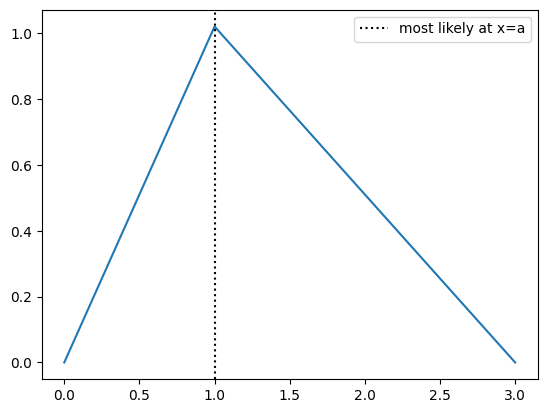

Probability that particle is to the left of x=a:  0.3474948158842736
Expectation value of x:  1.3031072569955664


In [2]:
# Problem 1.4

def psi0(x, A, a, b):
  if x > 0 and x <= a:
    return A * x / a
  elif x > a and x <= b:
    return A*(b-x)/(b-a)
  else:
    return 0

psi_series = lambda x_series, A, a, b :  np.array([psi0(x, A, a, b) for x in x_series])

def normalize_psi0(a, b, precision=1000):

  x_series = np.linspace(0, b, precision)
  A_guess_series = np.linspace(0, 10*b, precision)

  for A_guess in A_guess_series:

    normalization_integral = integrate(y = psi_series(x_series,
                                                      A_guess,
                                                      a,
                                                      b)**2,
                                       x = x_series)
    #print(normalization_integral)

    if np.abs(normalization_integral - 1) < 0.05:
      A = A_guess

  # Check normalization
  normalization_integral = integrate(y = psi_series(x_series, A, a, b)**2, x = x_series)
  print('Normalization: ', normalization_integral)

  return A

# The problem encourages the customization of a and b
a = 1
b = 3
A = normalize_psi0(a, b)

print('A: ', A)

# Plot psi(x, 0)
x_series = np.linspace(0, b, 1000)
psi0_series = psi_series(x_series, A, a, b)
plt.plot(x_series, psi0_series)
plt.axvline(a, linestyle='dotted', color='black', label='most likely at x=a')
plt.legend()
plt.show()

# Finding probability that the particle is to the left of x=a

x_left_a_series = np.linspace(0, a, 1000)
psi_left_a_series = psi_series(x_left_a_series, A, a, b)

probability_left_a = integrate(y= psi_left_a_series**2, x=x_left_a_series)
print('Probability that particle is to the left of x=a: ', probability_left_a)

# Finding the expectation value of x

expectation_value = integrate(x_series * psi0_series**2, x_series)
print('Expectation value of x: ', expectation_value)







Normalization: 1 =  A**2/λ
Standard deviation:  sqrt(2)/(2*λ)


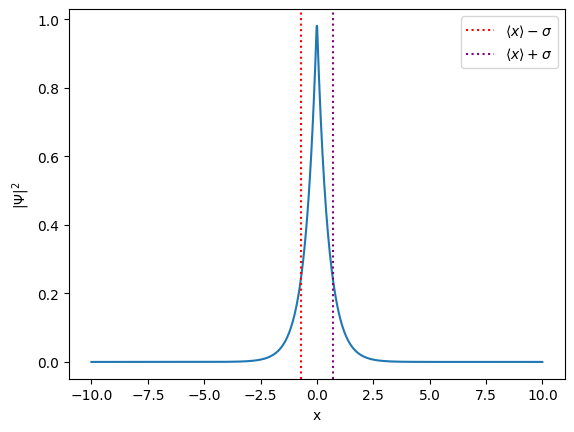

Probability found outside standard deviation:  0.24391677702365316


In [3]:
# Problem 1.5 requires a more analytical strategy

# $e^{-i\omega t}$ is a phase, so it can be ignored during the normalization.

# If we don't specify what's positive real, then sympy assumes it can be complex
x = sp.Symbol('x')
λ = sp.Symbol('λ', positive = True)
ω = sp.Symbol('ω', positive = True)
t = sp.Symbol('t')
A = sp.Symbol('A', positive = True)

normalization_integral = sp.integrate((A * sp.E**(-λ*sp.Abs(x)))**2,
                                      (x, -sp.oo, sp.oo))

print('Normalization: 1 = ', normalization_integral)

# This result is telling us that the normalization integral is $A^2/\lambda$
# for all positive real values of $\lambda$. The problem says $\lambda$ is
# positive real, so that means we can sole A**2/λ = 1 -->

A = sp.sqrt(λ)

# b)
expectation_x = sp.integrate(x*(A * sp.E**(-λ*sp.Abs(x)))**2,(x, -sp.oo, sp.oo))
expectation_x_sq = sp.integrate(x**2*( A * sp.E**(-λ*sp.Abs(x)))**2,(x, -sp.oo, sp.oo))

standard_deviation = sp.sqrt(expectation_x_sq - expectation_x**2)
print('Standard deviation: ', standard_deviation)

# Sketch the graph of the probabillity density

λ = 1
x_series = np.linspace(-10, 10, 1000)
get_psi_series = lambda λ, x_series : np.sqrt(λ) * np.exp(-λ*np.abs(x_series))

std = 1 / np.sqrt(2) / λ

psi_series = get_psi_series(λ, x_series)

plt.plot(x_series, psi_series**2)
plt.axvline(-std, linestyle='dotted', color='red', label=r'$\langle x \rangle - \sigma$')
plt.axvline(std, linestyle='dotted', color='purple', label=r'$\langle x \rangle + \sigma$')
plt.xlabel('x')
plt.ylabel(r'$|\Psi|^2$')
plt.legend()
plt.show()

# What is the probability that the particle would be found outside the std range?

left_x_series = np.linspace(-100, -std, 1000)
left_psi_series = get_psi_series(λ, left_x_series)

right_x_series = np.linspace(std, 100, 1000)
right_psi_series = get_psi_series(λ, right_x_series)

probability_left = integrate(y = left_psi_series**2, x = left_x_series)
probability_right = integrate(y = right_psi_series**2, x = right_x_series)

print('Probability found outside standard deviation: ', probability_left+probability_right)


# Problem 1.7 on Momentum

Eq. 1.33

$$\langle p\rangle = -i\hbar \int \left(\Psi^* \frac{\partial \Psi}{\partial x}\right)dx$$

$$\frac{ d \langle p\rangle }{dt}= -i\hbar \int \frac{d}{dt}\left(\Psi^* \frac{\partial \Psi}{\partial x}\right)dx$$

$$\frac{ d \langle p\rangle }{dt}= -i\hbar \int \left( \frac{\partial\Psi^*}{\partial t}\frac{\partial \Psi}{\partial x} + \Psi^* \frac{\partial }{\partial t}\frac{\partial \Psi}{\partial x}\right)dx$$

$$\frac{ d \langle p\rangle }{dt}= -i\hbar \int \left( \frac{\partial\Psi^*}{\partial t}\frac{\partial \Psi}{\partial x} + \Psi^* \frac{\partial }{\partial x}\frac{\partial \Psi}{\partial t}\right)dx$$

The Schrodinger equation gives us

$$\frac{\partial \Psi}{\partial t} = \frac{i\hbar}{2m}\frac{\partial^2 \Psi}{\partial x^2} - \frac{i}{\hbar}V\Psi$$
and, in the complex conjugate,

$$\frac{\partial \Psi^*}{\partial t} = -\frac{i\hbar}{2m}\frac{\partial^2 \Psi^*}{\partial x^2} + \frac{i}{\hbar}V\Psi^*$$

so

$$\frac{ d \langle p\rangle }{dt}= -i\hbar \int \left( \left[ -\frac{i\hbar}{2m}\frac{\partial^2 \Psi^*}{\partial x^2} + \frac{i}{\hbar}V\Psi^*\right]\frac{\partial \Psi}{\partial x} + \Psi^* \frac{\partial }{\partial x}\left[\frac{i\hbar}{2m}\frac{\partial^2 \Psi}{\partial x^2} - \frac{i}{\hbar}V\Psi\right]\right)dx $$

and

$$\frac{i}{\hbar}\frac{ d \langle p\rangle }{dt} = -\frac{i\hbar}{2m}\int \frac{\partial^2\Psi^*}{\partial x^2}\frac{\partial\Psi}{\partial x}dx \\ + \frac{i}{\hbar}\int V\Psi^* \frac{\partial \Psi}{\partial x} dx  \\ +\int \Psi^* \frac{\partial }{\partial x}\left[\frac{i\hbar}{2m}\frac{\partial^2 \Psi}{\partial x^2} - \frac{i}{\hbar}V\Psi\right]dx$$

therefore

$$\frac{i}{\hbar}\frac{ d \langle p\rangle }{dt} = -\frac{i\hbar}{2m}\int \frac{\partial^2\Psi^*}{\partial x^2}\frac{\partial\Psi}{\partial x}dx \\ + \frac{i}{\hbar}\int V\Psi^* \frac{\partial \Psi}{\partial x} dx  \\ +\int \Psi^* \frac{i\hbar}{2m}\frac{\partial^3 \Psi}{\partial x^3} dx \\-\frac{i}{\hbar} \int \Psi^*\left(\frac{\partial V}{\partial x}\Psi + V\frac{\partial \Psi}{\partial x}\right)dx$$

and

$$\frac{i}{\hbar}\frac{ d \langle p\rangle }{dt} = -\frac{i\hbar}{2m}\int \frac{\partial^2\Psi^*}{\partial x^2}\frac{\partial\Psi}{\partial x}dx \\ + \frac{i}{\hbar}\int V\Psi^* \frac{\partial \Psi}{\partial x} dx  \\ +\frac{i\hbar}{2m}\int \Psi^* \frac{\partial^3 \Psi}{\partial x^3} dx \\-\frac{i}{\hbar} \int \Psi^*\frac{\partial V}{\partial x}\Psi dx - \frac{i}{\hbar}\int \Psi^* V\frac{\partial \Psi}{\partial x}dx$$

Since the operator $V=V(x)$ acts by multiplication of a scalar-valued function, we can cancel two terms:

$$\frac{i}{\hbar}\frac{ d \langle p\rangle }{dt} = -\frac{i\hbar}{2m}\int \frac{\partial^2\Psi^*}{\partial x^2}\frac{\partial\Psi}{\partial x}dx \\ +\frac{i\hbar}{2m}\int \Psi^* \frac{\partial^3 \Psi}{\partial x^3} dx \\-\frac{i}{\hbar} \int \Psi^*\frac{\partial V}{\partial x}\Psi dx$$

Now, to do integration by parts on the term:

$$\int \Psi^* \frac{\partial^3 \Psi}{\partial x^3} dx = uv - \int v \frac{\partial u}{\partial x} dx$$

Choose $u = \Psi^*$ to be simpler differentiate, and $v = \frac{\partial^3 \Psi}{\partial x^3}$ to be simpler to integrate.

$$\int \Psi^* \frac{\partial^3 \Psi}{\partial x^3} dx =  \left. \left[ \Psi^*  \frac{\partial^2 \Psi}{\partial x^2} \right] \right|_{-\infty}^{\infty}- \int  \frac{\partial^2 \Psi}{\partial x^2} \frac{\partial \Psi^*}{\partial x} dx$$

Boundary conditions: $\left. \left[ \Psi^*  \frac{\partial^2 \Psi}{\partial x^2} \right] \right|_{-\infty}^{\infty} = 0$.

So

$$\int \Psi^* \frac{\partial^3 \Psi}{\partial x^3} dx =  - \int  \frac{\partial^2 \Psi}{\partial x^2} \frac{\partial \Psi^*}{\partial x} dx$$

And we need to perform integration by parts one more time with the boundary conditions:
$$\int  \frac{\partial^2 \Psi}{\partial x^2} \frac{\partial \Psi^*}{\partial x} dx = \left.\left[\frac{\partial \Psi}{\partial x} \frac{\partial \Psi^*}{\partial x}\right]\right|_{-\infty}^{\infty} - \int  \frac{\partial^2 \Psi^*}{\partial x^2} \frac{\partial \Psi}{\partial x} dx = - \int  \frac{\partial^2 \Psi^*}{\partial x^2} \frac{\partial \Psi}{\partial x} dx$$

Substituting back in,

$$\frac{i}{\hbar}\frac{ d \langle p\rangle }{dt} = -\frac{i\hbar}{2m}\int \frac{\partial^2\Psi^*}{\partial x^2}\frac{\partial\Psi}{\partial x}dx \\ +\frac{i\hbar}{2m}\int  \frac{\partial^2 \Psi^*}{\partial x^2} \frac{\partial \Psi}{\partial x} dx \\-\frac{i}{\hbar} \int \Psi^*\frac{\partial V}{\partial x}\Psi dx$$

Canceling and dividing by $\frac{i}{\hbar}$ on both sides,

$$\frac{d\langle p \rangle}{dt} = - \int \Psi^*\frac{\partial V}{\partial x}\Psi dx$$

According to the text, that's the expectation value

$$\frac{d\langle p \rangle}{dt} = - \left\langle \frac{\partial V}{\partial x}\right\rangle,$$

"This is an instance of Ehrenfest's theorem, which asserts that expectation values obey the classical laws."


# Problem 1.8

Let's add a constant $V_0$ to the potential energy in the Schrodinger equation.

$$i\hbar\frac{\partial \Phi}{\partial t} = -\frac{\hbar^2}{2m}\frac{\partial^2\Phi}{\partial x^2} + (V+V_0)\Phi$$

$$\frac{\partial \Phi}{\partial t} + \frac{i}{\hbar}V_0 \Phi = -\frac{1}{i}\frac{\hbar}{2m}\frac{\partial^2\Phi}{\partial x^2} - \frac{i}{\hbar}V\Phi$$

Compare this to if we add a phase to the wavefunction in the Schrodinger equation,

$$i\hbar\frac{\partial}{\partial t}\left(e^{-iV_0t/\hbar}\Psi\right) = -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}\left(e^{-iV_0t/\hbar}\Psi\right) + Ve^{-iV_0t/\hbar}\Psi$$

$$i\hbar\left(-\frac{iV_0}{\hbar}e^{-iV_0t/\hbar}\Psi + \frac{\partial\Psi}{\partial t}e^{-iV_0t/\hbar}\right) = -\frac{\hbar^2}{2m}\left(e^{-iV_0t/\hbar}\frac{\partial^2 \Psi}{\partial x^2}\right) + Ve^{-iV_0t/\hbar}\Psi$$

$$i\hbar \frac{\partial\Psi}{\partial t}e^{-iV_0t/\hbar} = -\frac{\hbar^2}{2m}\left(e^{-iV_0t/\hbar}\frac{\partial^2 \Psi}{\partial x^2}\right) + V_0e^{-iV_0t/\hbar}\Psi + Ve^{-iV_0t/\hbar}\Psi$$

Divide by the factor on both sides,


$$i\hbar \frac{\partial\Psi}{\partial t} = -\frac{\hbar^2}{2m}\left(\frac{\partial^2 \Psi}{\partial x^2}\right) + V_0\Psi + V\Psi$$

The result is the same as adding a constant to the potential energy.



# Problem 1.9

## a
$$\Psi(x, t) = A e^{-a[(mx^2/\hbar) + it]} = A e^{-a(mx^2/\hbar)}e^{-ait}$$

Normalize $\Psi(x, 0)$:

$$1 = \int |\Psi|^2 dx = \int A^2 e^{-2a(mx^2/\hbar)} dx $$

The integral of an arbitrary Gaussian function is

$$\int_{-\infty}^{\infty} e^{c(x+d)^2} dx = \sqrt{\frac{\pi}{c}}$$

which means

$$ 1 = A^2\sqrt{\frac{\hbar\pi}{2am}}$$

$$A = \sqrt[4]{\frac{2am}{\hbar \pi}}$$

$$\Psi(x, t) = \sqrt[4]{\frac{2am}{\hbar \pi}} e^{-a(mx^2/\hbar)}e^{-ait}$$

## b

For what potential energy function is this a solution to the Schrodinger equation?

$$\frac{\partial\Psi}{\partial t} = -ai\sqrt[4]{\frac{2am}{\hbar \pi}} e^{-a(mx^2/\hbar)}e^{-ait}$$

$$\frac{\partial\Psi}{\partial x} = \sqrt[4]{\frac{2am}{\hbar \pi}}(-2amx/\hbar) e^{-a(mx^2/\hbar)}e^{-ait}$$

$$\frac{\partial^2\Psi}{\partial x^2} = \sqrt[4]{\frac{2am}{\hbar \pi}}\left((-2am/\hbar) e^{-a(mx^2/\hbar)} +(2amx/\hbar)^2 e^{-a(mx^2/\hbar)} \right)e^{-ait}$$

$$i\hbar\frac{\partial\Psi}{\partial t} = -\frac{\hbar^2}{2m}\frac{\partial^2\Psi}{\partial x^2} + V\Psi$$

$$\hbar a\sqrt[4]{\frac{2am}{\hbar \pi}} e^{-a(mx^2/\hbar)}e^{-ait} = -\frac{\hbar^2}{2m}\left[\sqrt[4]{\frac{2am}{\hbar \pi}}\left((-2am/\hbar) e^{-a(mx^2/\hbar)} +(2amx/\hbar)^2 e^{-a(mx^2/\hbar)} \right)e^{-ait}\right] + V\Psi$$

simplifying

$$\hbar a\sqrt[4]{\frac{2am}{\hbar \pi}} e^{-a(mx^2/\hbar)}e^{-ait} = \left[\sqrt[4]{\frac{2am}{\hbar \pi}}\left(\hbar a e^{-a(mx^2/\hbar)} -2a^2mx^2 e^{-a(mx^2/\hbar)} \right)e^{-ait}\right] + V\Psi$$

Cancel $\hbar a\sqrt[4]{\frac{2am}{\hbar \pi}} e^{-a(mx^2/\hbar)}e^{-ait}$ from both sides

$$0 = -\sqrt[4]{\frac{2am}{\hbar \pi}}\cdot 2a^2mx^2 e^{-a(mx^2/\hbar)}e^{-ait} + V\Psi$$

Recall

$$\Psi(x, t) = \sqrt[4]{\frac{2am}{\hbar \pi}} e^{-a(mx^2/\hbar)}e^{-ait}$$

Therefore $V = 2a^2mx^2$.

## c

Calculation the expectation values $\langle x \rangle$, $\langle x^2 \rangle$, $\langle p \rangle$, $\langle p^2 \rangle$.

$$\Psi =  \sqrt[4]{\frac{2am}{\hbar \pi}} e^{-a(mx^2/\hbar)}e^{-ait}$$
$$\Psi^* = \sqrt[4]{\frac{2am}{\hbar \pi}} e^{-a(mx^2/\hbar)}e^{+ait}$$

$$\langle x \rangle = \int \Psi^* x \Psi dx $$

$$\langle x \rangle = \sqrt{\frac{2am}{\hbar \pi}}\int x e^{-2a(mx^2/\hbar)} dx $$

Since $x e^{-2a(mx^2/\hbar)}$ is an odd function symmetric around $x=0$, we can conclude the integral is zero.



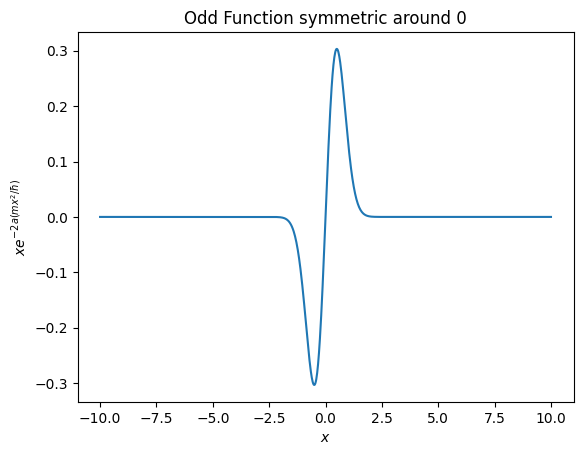

In [4]:
m = 1
a = 1
hbar = 1

def f(x):
  return np.exp(-2*a*m*x**2 / hbar)

x_series = np.linspace(-10, 10, 1000)

plt.plot(x_series, x_series*f(x_series))
plt.title('Odd Function symmetric around 0')
plt.ylabel(r'$xe^{-2a(mx^2/\hbar)}$')
plt.xlabel(r'$x$')
plt.show()

$\therefore\quad \langle x \rangle = 0$

$$\langle x^2 \rangle = \sqrt{\frac{2am}{\hbar \pi}}\int x^2 e^{-2a(mx^2/\hbar)}$$

$x^2 e^{-2a(mx^2/\hbar)}$ is an even function, so


$$\langle x^2 \rangle = 2\sqrt{\frac{2am}{\hbar \pi}}\int_0^{\infty}x^2 e^{-2a(mx^2/\hbar)}$$

According to integral tables,

$$\int_0^{\infty}x^m e^{-ax^2} dx = \frac{\Gamma[(m+1)/2]}{2a^{(m+1)/2}}$$

$$\int_0^{\infty}x^2 e^{-2amx^2/\hbar} dx = \frac{\Gamma[3/2]}{2(2am/\hbar)^{3/2}}$$

$\Gamma[3/2] = \frac{1}{2}\sqrt{\pi}$

$$\int_0^{\infty}x^2 e^{-2amx^2/\hbar} dx = \frac{\sqrt{\pi}}{4(2am/\hbar)^{3/2}}$$

$$\int_0^{\infty}x^2 e^{-2amx^2/\hbar} dx = \frac{\sqrt{\frac{\hbar\pi}{2am}}}{4(2am/\hbar)}$$

Plugging in,

$$\langle x^2 \rangle = 2\sqrt{\frac{2am}{\hbar \pi}}\frac{\sqrt{\frac{\hbar\pi}{2am}}}{4(2am/\hbar)} = \frac{\hbar}{4am}$$

As for momentum,

$$\langle p \rangle = \int \Psi^* p \Psi dx = -i\hbar\int \left(\Psi^*\frac{\partial \Psi}{\partial x}\right) dx$$

$$\Psi =  \sqrt[4]{\frac{2am}{\hbar \pi}} e^{-a(mx^2/\hbar)}e^{-ait}$$
$$\Psi^* = \sqrt[4]{\frac{2am}{\hbar \pi}} e^{-a(mx^2/\hbar)}e^{+ait}$$
$$\frac{\partial \Psi}{\partial x} = -\frac{2amx}{\hbar}\sqrt[4]{\frac{2am}{\hbar \pi}}e^{-a(mx^2/\hbar)}e^{-ait}$$

$$\Psi^*\frac{\partial \Psi}{\partial x} = -\frac{2am}{\hbar}\sqrt{\frac{2am}{\hbar \pi}}xe^{-2a(mx^2/\hbar)}$$

$$\langle p \rangle = 2iam\sqrt{\frac{2am}{\hbar \pi}}\int xe^{-2a(mx^2/\hbar)} dx = 0$$

due to the integral over the odd function as described before.

$$\langle p^2 \rangle = \int \Psi^* p^2 \Psi dx = \int \Psi^*[-i\hbar(\frac{\partial }{\partial x})][-i\hbar(\frac{\partial }{\partial x})] \Psi dx \\= -\hbar^2\int \Psi^*  \frac{\partial^2 \Psi}{\partial x^2} dx$$

$$\frac{\partial^2 \Psi}{\partial x^2} = -\frac{2am}{\hbar}\sqrt[4]{\frac{2am}{\hbar \pi}}e^{-a(mx^2/\hbar)}e^{-ait} + \left(\frac{2amx}{\hbar}\right)^2\sqrt[4]{\frac{2am}{\hbar \pi}}e^{-a(mx^2/\hbar)}e^{-ait}$$

$$\frac{\partial^2 \Psi}{\partial x^2} = \left[\left(\frac{2amx}{\hbar}\right)^2-\frac{2am}{\hbar}\right]\sqrt[4]{\frac{2am}{\hbar \pi}}e^{-a(mx^2/\hbar)}e^{-ait}$$

$$\Psi^* \frac{\partial^2 \Psi}{\partial x^2} =\left[\left(\frac{2amx}{\hbar}\right)^2-\frac{2am}{\hbar}\right]\sqrt{\frac{2am}{\hbar \pi}}e^{-2a(mx^2/\hbar)} $$


The goal is to solve the integral

$$\langle p^2 \rangle = -\hbar^2\int\Psi^* \frac{\partial^2 \Psi}{\partial x^2}dx$$

$$\langle p^2 \rangle = \int \left[-(2amx)^2 + 2am\hbar\right]\sqrt{\frac{2am}{\hbar\pi}}e^{-2a(mx^2)/\hbar}dx$$


$$\langle p^2 \rangle = -\int [(2amx)^2]\sqrt{\frac{2am}{\hbar\pi}}e^{-2a(mx^2)/\hbar}dx + \int 2am\hbar \sqrt{\frac{2am}{\hbar\pi}}e^{-2a(mx^2)/\hbar}dx$$

Piece 2

$$2am\hbar\sqrt{\frac{2am}{\hbar\pi}}\int e^{-2a(mx^2)/\hbar}dx = 2am\hbar\sqrt{\frac{2am}{\hbar\pi}}\sqrt{\frac{\hbar\pi}{2am}} = 2am\hbar$$

Piece 1

$$-(2am)^2\sqrt{\frac{2am}{\hbar\pi}}\int x^2 e^{-2a(mx^2)/\hbar}dx$$

We found above that

$$\int_0^{\infty}x^2 e^{-2amx^2/\hbar} dx = \frac{\sqrt{\frac{\hbar\pi}{2am}}}{4(2am/\hbar)}$$

so

$$-(2am)^2\sqrt{\frac{2am}{\hbar\pi}}\int x^2 e^{-2a(mx^2)/\hbar}dx = \frac{-(2am)^2}{4am/\hbar}=-am\hbar$$

Therefore

$$\langle p^2 \rangle = \hbar(2am-am) = am\hbar$$

The uncertainty relation is

$$\sigma_x\sigma_p = \sqrt{\langle x^2 \rangle - \langle x \rangle^2}\sqrt{\langle p^2 \rangle - \langle p \rangle^2} \geq \frac{\hbar}{2}$$

which we can check with

$$\sigma_x\sigma_p = \sqrt{\frac{\hbar}{4am}}\sqrt{am\hbar} = \sqrt{\frac{\hbar^2}{4}} = \frac{\hbar}{2},$$

so the uncertainty relation is saturated for this wave function.



# Chapter 2: Time-independent Schrodinger equation

The time-independent Schrodinger equation is an eigenvalue equation for the Hamiltonian operator.

Problem 2.1

a)

Show the separation constant must be real

$$E = E_0 + i\Gamma$$

Equation 2.7

$$\Psi(x, t) = \psi(x)e^{-i(E_0+i\Gamma)t/\hbar} = \psi(x)e^{-i E_0t / \hbar}e^{\Gamma t/\hbar}$$

Equation 1.20

$$\int|\Psi(x, t)|^2 dx = 1$$

$$|\Psi(x, t)| = |\psi(x)| |e^{-iE_0t/\hbar}||e^{\Gamma t/\hbar}| =|\psi(x)||e^{\Gamma t/\hbar}|$$

$$\int|\Psi(x, t)|^2 dx = |e^{2\Gamma t / \hbar}|\int |\psi(x)|^2 dx = 1$$

$$\int|\psi(x)|^2dx = |e^{-2\Gamma t / \hbar}|$$

$\psi(x)$ is only normalized when $\Gamma = 0$, meaning when the separation constant $E$ is real.

b)



# Solving the Schrodinger Equation with Separation of variables to derive the time-independent Schrodinger Equation

The time-dependent (more fundamental) Schrodinger equation is
$$i\hbar\frac{\partial \Psi}{\partial t} = - \frac{\hbar}{2m}\frac{\partial^2 \Psi}{\partial x^2} + V\Psi $$

and we can approach it with **separation of variables**

$$\Psi(x, t) = \psi(x)\phi(t)$$

$$\frac{\partial \Psi}{\partial t} = \psi\frac{d \phi}{dt}, \quad \frac{\partial ^2}{\partial x^2} = \frac{d^2 \psi}{dx^2}\phi$$

(ordinary derivatives since $x$ is gone from $\phi(t)$ and $t$ is gone from $\psi(x)$), so now the Schrodinger equation reads

$$i\hbar \psi\frac{d \phi}{d t} = \frac{-\hbar}{2m}\frac{d^2 \psi}{dx^2}\phi + V\psi\phi$$

We can divide both sides by $\psi\phi$

$$i\hbar\frac{1}{\phi}\frac{d\phi}{dt} = \frac{-\hbar}{2m}\frac{1}{\psi}\frac{d^2\psi}{dx^2} + V = E$$
where $E$ is constant because the right-hand side is independent of $t$ (the independent variable of the left-hand side) and the left-hand side is independent of $x$ (the independent variable of the right-hand side).

Therefore

$$\frac{d\phi}{dt} = -i \frac{E}{\hbar} \phi$$

which implies

$$\phi = e^{-iEt/\hbar}$$

and the time-independent Schrodinger equation is

$$\frac{-\hbar}{2m}\frac{d^2\psi}{dx^2} + V\psi = E\psi$$

which can only be solved by specifying $V$.

The time-independent Schrodinger equation describes **stationary states** because the probability density is independent of time

$$\Psi^*\Psi =\psi^* e^{+iEt/\hbar} e^{=iEt/\hbar} \psi = |\psi(x)|^2$$

and the expectation values are constant in time as well, for the same cancelation happens:

$$\langle Q(x, p)\rangle = \int \psi^* \left[Q\left(x, -i\hbar\frac{d}{dx}\right)\right]\psi dx$$

As there is a **Hamiltonian operator**

$$\hat{H} = -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x)$$

the time-independent Schrodinger equation reads

$$\hat{H}\psi = E\psi$$

with expectation values

$$\langle H \rangle = \int \psi^* \hat{H}\psi dx = E\int |\psi|^2dx = E$$

$$\langle H^2 \rangle = \int \psi^* \hat{H}\hat{H}\psi dx = E\langle H\rangle = E^2$$

and variance

$$\sigma_H^2 = \langle H^2\rangle - \langle H \rangle^2 = E^2 - E^2 = 0$$

so every measurement of the total energy is certain to return the value $E$.

Each solution of the time-dependent Schrodinger equation is a linear combination of solutions of the time-independent Schrodinger equation, as long as $V(x)$ is independent of $t$.




Problem 2.1b

Show the time-independent wave function $\psi(x)$ can always be taken to be real.

Hint: If $\psi(x)$ satisfies Equation 2.5, so does $\psi^*$, $(\psi+\psi^*)$, and $i(\psi-\psi^*)$.

The goal is not to show that the solution is always real, but that any complex solution can be expressed as a linear combination of real solutions.

$$\psi = \text{Re}\psi + i\text{Im}\psi$$
$$\psi^* = \text{Re}\psi -i\text{Im}\psi$$

The real part is a linear combination, and therefore a solution

$$\psi+\psi^* = 2\text{Re}\psi \quad\therefore\quad \text{Re}\psi = \frac{\psi + \psi^*}{2}$$

and the imaginary part is a linear combination, and therefore a solution

$$\psi - \psi^* = 2i\text{Im}\psi \quad\therefore\quad \text{Im}\psi = \frac{\psi - \psi^*}{2i}$$

$\psi^*$ is a solution because we can take the complex conjugate of both sides of the TISE

$$\frac{-\hbar}{2m}\frac{d^2\psi^*}{dx^2} + V\psi^* = E\psi^*,$$

therefore the real and imaginary parts can be taken as real solutions for the equation, even for complex $\psi$.

Problem 2.1c

Show that if $V(x)$ is an even function, then $\psi(x)$ can be taken to be either even or odd.

If $\psi(x)$ satisfies Equation 2.5, for a given $E$, then so does $\psi(-x)$ and also the even and odd linear combinations $\psi(x)\pm \psi(-x)$.

If $V(x)$ is an even function, then

$$V(-x) = V(x)$$

so for the same TISE

$$\frac{-\hbar}{2m}\frac{d^2\psi(x)}{dx^2} + V(x)\psi(x) = E\psi(x)$$

can take an input of $-x$ on both sides

$$\frac{-\hbar}{2m}\frac{d^2\psi(-x)}{dx^2} + V(x)\psi(-x) = E\psi(-x)$$

and $\psi(-x)$ and $\psi(x)$ are solutions to the same Schrodinger equation.

For any function $\psi(x)$, the linear combination $\psi(x) + \psi(-x)$ is even and $\psi(x) - \psi(-x)$ is odd. These even and odd linear combinations are also solutions to the linear ODE. Therefore an even or odd solution can always be found.








Problem 2.2

Rewrite the Schrodinger equation in the form

$$\frac{d^2 \psi}{dx^2} = \frac{2m}{\hbar^2}[V(x) - E]\psi$$

If $E<V_{\text{min}}$, then $\frac{2m}{\hbar^2}[V(x) - E]>0$ and $\psi$ and $\frac{ d^2\psi}{d x^2}$ and $\psi$ always have the same sign. Such a function cannot be normalized because the integral under the probability density will be infinite. Therefore all physical solutions to the equation must involve $E>V_{\text{min}}$. The classical analog to this result is the non-negativity of kinetic energy.

# The Infinite Square Well

The potential function

$$V(x) = \begin{cases}
  0, & 0\leq x \leq a \\
  \infty, & \text{otherwise}
  \end{cases}$$

leads to $\psi(x)=0$ outside the well, and, inside the well, a time-independent Schrodinger equation

$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} = E\psi$$

or

$$\frac{d^2\psi}{dx^2} = -k^2\psi, \quad \text{where } k = \frac{\sqrt{2mE}}{\hbar}$$

with $E\geq 0$ as shown in the previous problem.

The general solution to this equation is

$$\psi(x) = A\sin kx + B \cos kx$$

Continuity of $\psi(x)$ requires

$$\psi(0) = \psi(a) = 0$$

$$\psi(0) = A\sin 0 + B\cos 0 = B \quad\therefore\quad B = 0$$

$$\psi(x) = A\sin kx$$

In order for $\psi(a) = 0$, we must have solutions $ka = \pm n\pi$, where $n$ is an integer. This gives us a set of possibile values of $k$

$$k_n = \frac{n\pi}{a}$$

which translates into a set of possible values of $E$

$$E_n = \frac{\hbar^2k_n^2}{2m} = \frac{\hbar^2n^2\pi^2}{2ma^2}$$

and a set of possible solutions

$$\psi_n(x) = A\sin\left(\frac{n\pi}{a}x\right)$$

where $A$ normalizes $\psi$ like so

$$\int_0^a |A|^2\sin^2(kx) dx = |A|^2 \frac{a}{2} = 1$$

$$\psi_n(x) = \sqrt{\frac{2}{a}}\sin\left(\frac{n\pi}{a}x\right)$$

$E_1$ is the energy of the ground state $\psi_1(x)$, and the rest are excited states.


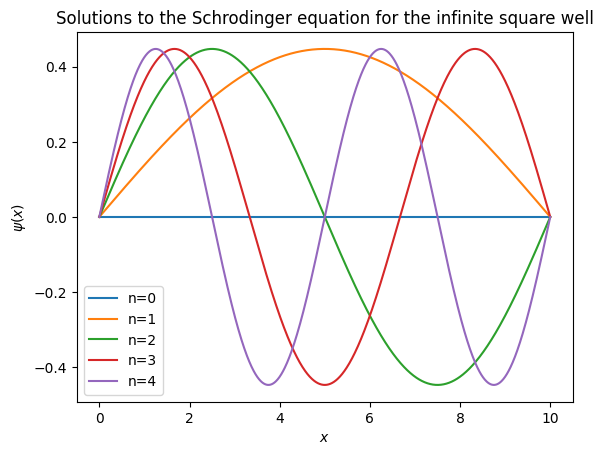

In [5]:
psi_n = lambda a, n, x: np.sqrt(2/a)*np.sin(n*np.pi * x / a)

a = 10

x_series = np.linspace(0, a, 1000)

for n in range(5):
  plt.plot(x_series, psi_n(a, n, x_series), label=f'n={n}')
plt.title('Solutions to the Schrodinger equation for the infinite square well')
plt.ylabel(r'$\psi(x)$')
plt.xlabel(r'$x$')
plt.legend()
plt.show()

These solutions are alternatively even and odd. Each successive state has one more node. The solutions are orthonormal

$$\int\psi_m(x)^*\psi_n(x)dx = \delta_{mn}$$

Any function can be expressed as a linear combination of these solutions (the Fourier series)

$$f(x) = \sum_{n=1}^{\infty} c_n\psi_n(x) = \sqrt{\frac{2}{a}}\sum_{n=1}^\infty c_n\sin(\frac{n\pi}{a}x)$$

and the coefficients are given by the following integrals ("Fourier's trick")

$$c_m=\int \psi_m(x)^*f(x)dx = \sum_{n=1}^{infty} \int \psi(x)^*\psi_n(x) = \sum_{n=1}^\infty c_n\delta_{mn} = c_m$$

The stationary states of the infinite square well are

$$\Psi_n(x, t) = \sqrt{\frac{2}{a}}\sin(\frac{n\pi}{a}x)e^{-in^2\pi^2\hbar t/2ma^2}$$

and the solution to the wavefunction is a linear combination of these

$$\Psi(x, t) = \sum_{n=1}^\infty c_n\sqrt{\frac{2}{a}}\sin(\frac{n\pi}{a}x)e^{-in^2\pi^2\hbar t/2ma^2}$$

The initial condition is found by plugging in $t=0$

$$\Psi(x, 0) = \sum_{n=1}^{\infty} c_n \psi_n(x)$$

and the coefficients can be found via the above Fourier's trick

$$c_n= \int \psi^* \Psi(x, 0) dx \\= \int \sqrt{\frac{2}{a}}\sin\left(\frac{n\pi}{a}x\right)\Psi(x, 0)dx$$

 Problem 2.4

Verify the uncertainty principle for the nth stationary state of the infinite square well.

These are the integrals we need to solve:

$$\langle x \rangle = \int \Psi^* x \Psi dx $$

$$\langle x^2 \rangle = \int \Psi^* x^2 \Psi dx $$

$$\langle p \rangle = \int \Psi^* p \Psi dx = -i\hbar\int \left(\Psi^*\frac{\partial \Psi}{\partial x}\right) dx$$

$$\langle p^2 \rangle = \int \Psi^* p^2 \Psi dx = \int \Psi^*[-i\hbar(\frac{\partial }{\partial x})][-i\hbar(\frac{\partial }{\partial x})] \Psi dx \\= -\hbar^2\int \Psi^*  \frac{\partial^2 \Psi}{\partial x^2} dx$$

This is the wavefunction in question:


$$\Psi_n(x, t) = \sqrt{\frac{2}{a}}\sin(\frac{n\pi}{a}x)e^{-in^2\pi^2\hbar t/2ma^2}$$

but the time-dependent terms will all cancel with the complex conjugate, so we can get away with considering only

$$\psi_n(x) = \sqrt{\frac{2}{a}}\sin\left(\frac{n\pi}{a}x\right)$$

$$\psi_n(x)^* = \psi_n(x)$$

$$\frac{\partial \psi_n(x)}{\partial x} = \sqrt{\frac{2}{a}}\frac{n\pi}{a}\cos\left(\frac{n\pi}{a}x\right)$$

$$\frac{\partial^2 \psi_n(x)}{\partial x^2} = -\sqrt{\frac{2}{a}}\frac{n^2\pi^2}{a^2}\sin\left(\frac{n\pi}{a}x\right)$$

In [6]:
x = sp.Symbol('x')
a = sp.Symbol('a', positive=True)
n = sp.Symbol('n', integer=True, positive=True)
hbar = sp.Symbol('hbar', positive=True)
psi_n = sp.sqrt(2/a)*sp.sin(n*sp.pi/a * x)

d_psi_n_x = sp.diff(psi_n, x)
d2_psi_n_x2 = sp.diff(d_psi_n_x, x)

expected_position = sp.integrate(psi_n*x*psi_n, (x, 0, a))
print('expected position: ', expected_position)

expected_position_squared = sp.integrate(psi_n*x**2*psi_n, (x, 0, a))
print('expected position squared', expected_position_squared)

expected_momentum = sp.integrate(-sp.I*hbar*psi_n*d_psi_n_x, (x, 0, a))
print('expected momentum: ', expected_momentum)

expected_momentum_squared = sp.integrate(-hbar**2*psi_n*d2_psi_n_x2, (x, 0, a))
print('expected momentum squared: ', expected_momentum_squared)

variance_position = expected_position_squared - expected_position**2
variance_momentum = expected_momentum_squared - expected_momentum**2

uncertainty_relation = sp.sqrt(variance_position*variance_momentum)
print('σ_x σ_p = ', uncertainty_relation.simplify())

expected position:  a/2
expected position squared 2*(a**3/6 - a**3/(4*pi**2*n**2))/a
expected momentum:  0
expected momentum squared:  pi**2*hbar**2*n**2/a**2
σ_x σ_p =  hbar*sqrt(3*pi**2*n**2 - 18)/6


$$\sigma_x^2\sigma_p^2 = \hbar^2\left(\frac{\pi^2n^2}{12}- \frac{1}{2}\right) \geq \frac{\hbar^2}{4}$$

$$\frac{\pi^2n^2}{12} \geq \frac{3}{4}$$

In [7]:
print(np.pi**2/12)

0.8224670334241132


The above satisfies the uncertainty relation. The lower the value of n, the closer to saturation.

Problem 2.5

In [8]:
psi_1 = sp.sqrt(2/a)*sp.sin(sp.pi/a * x)
psi_2 = sp.sqrt(2/a)*sp.sin(2*sp.pi/a * x)

A = sp.Symbol('A', positive=True)
Psi_x_0 = A * (psi_1 + psi_2)

# Normalize Psi_x_0
normalization_integral = sp.integrate(sp.conjugate(Psi_x_0)*Psi_x_0, (x, 0, a))
print(normalization_integral)
# 2*A**2 = 1 --> A = sqrt(1/2)
A = sp.sqrt(1/2)
Psi_x_0 = A * (psi_1 + psi_2)

m = sp.Symbol('m', positive=True)
t = sp.Symbol('t', positive=True)
omega = sp.pi**2 * hbar / (2*m*a**2)

c_1 = sp.integrate(sp.conjugate(psi_1)*Psi_x_0, (x, 0, a))
c_2 = sp.integrate(sp.conjugate(psi_2)*Psi_x_0, (x, 0, a))

print('c_1:', c_1)
print('c_2:', c_2)
# c_n is zero for all other n, because of orthogonality.

2*A**2
c_1: 0.707106781186548
c_2: 0.707106781186548


$$\Psi(x, 0) = \sqrt{\frac{1}{a}}\left( \sin(\frac{\pi}{a}x) + \sin(\frac{2\pi}{a}x)\right)$$

$$c_n = \sqrt{\frac{1}{a}}\int\sin\left(\frac{n\pi}{a} x\right)\Psi(x, 0)dx$$

Following equation 2.39

$$\Psi(x, t) = \sqrt{\frac{1}{a}}\left( \sin(\frac{\pi}{a}x)e^{-i\omega t} + \sin(\frac{2\pi}{a}x)e^{-4i\omega t}\right)$$


$$\Psi(x, t)^* = \sqrt{\frac{1}{a}}\left( \sin(\frac{\pi}{a}x)e^{+i\omega t} + \sin(\frac{2\pi}{a}x)e^{+4i\omega t}\right)$$

$$|\Psi(x, t)|^2 = \Psi(x, t)^*\Psi(x, t)$$

$$|\Psi(x, t)|^2 = \frac{1}{a}\left(\sin^2(\frac{\pi}{a}x) + \sin(\frac{\pi}{a}x)\sin(\frac{2\pi}{a}x)e^{-3i\omega t} + \sin(\frac{\pi}{a}x)\sin(\frac{2\pi}{a}x)e^{+3i\omega t} + \sin^2(\frac{2\pi}{a}x)\right)$$


$$|\Psi(x, t)|^2 = \frac{1}{a}\left(\sin^2(\frac{\pi}{a}x) + \sin(\frac{\pi}{a}x)\sin(\frac{2\pi}{a}x)(e^{-3i\omega t}+e^{+3i\omega t}) + \sin^2(\frac{2\pi}{a}x)\right)$$

$$|\Psi(x, t)|^2 = \frac{1}{a}\left(\sin^2(\frac{\pi}{a}x) + 2\sin(\frac{\pi}{a}x)\sin(\frac{2\pi}{a}x)\cos(3\omega t) + \sin^2(\frac{2\pi}{a}x)\right)$$








In [9]:
probability_density = 1/a*(sp.sin(sp.pi/a*x)**2 + 2*sp.sin(sp.pi/a*x)*sp.sin(2*sp.pi/a*x)*sp.cos(3*omega*t) + sp.sin(2*sp.pi/a*x)**2)

expected_position = sp.simplify(sp.integrate(probability_density*x, (x, 0, a)))

print(expected_position)


-16*a*cos(3*pi**2*hbar*t/(2*a**2*m))/(9*pi**2) + a/2


$$\langle x \rangle = \frac{a}{2} -\frac{16a}{9\pi^2}\cos(3\omega t)$$

$$\langle p \rangle = \int \Psi^* p \Psi dx = -i\hbar\int \left(\Psi^*\frac{\partial \Psi}{\partial x}\right) dx$$

In [10]:
Psi_x_t = sp.sqrt(1/a)*(sp.sin(sp.pi/a*x)*sp.exp(-sp.I*omega*t) + sp.sin(2*sp.pi/a*x)*sp.exp(-4*sp.I*omega*t))

d_Psi_x_t_dx = sp.diff(Psi_x_t, x)

expected_momentum = -sp.I * hbar * sp.integrate(sp.conjugate(Psi_x_t)*d_Psi_x_t_dx, (x, 0, a))
print(sp.expand(expected_momentum).simplify())

8*hbar*sin(3*pi**2*hbar*t/(2*a**2*m))/(3*a)


$$\langle p \rangle = \frac{8\hbar}{3a}\sin\left(3\omega t\right)$$

The energies are given by Equation 2.30

$$E_1 = \frac{\pi^2\hbar^2}{2ma^2}$$

$$E_2 = \frac{4\pi^2\hbar^2}{2ma^2}$$

and the probabilities are given by the squared coefficients

$$|c_1|^2 = |c_2|^2 = \frac{1}{2}$$

The expected energy is

$$\langle H \rangle = \frac{1}{2}\frac{\pi^2\hbar^2}{2ma^2} + \frac{1}{2}\frac{4\pi^2\hbar^2}{2ma^2} = \frac{1.25\pi^2\hbar^2}{ma^2}$$

 Problem 2.6

 $$\Psi(x, 0) = A[\psi_1(x) + e^{i\phi}\psi_2(x)]$$

 $$\int |\Psi(x,0)|^2 dx= A^2\int [\psi_1(x) + e^{-i\phi}\psi_2(x)]  [\psi_1(x) + e^{+i\phi}\psi_2(x)]dx$$

 $$\int |\Psi(x,0)|^2 dx= A^2\left[\int \psi_1(x)^2 dx + \int\psi_1(x) e^{-i\phi}\psi_2(x)dx+ \int e^{+i\phi}\psi_1(x)\psi_2(x) dx + \int \psi_2(x)^2 dx\right] = 2A^2 = 1$$

 $$\therefore\quad A = \sqrt{\frac{1}{2}}$$


 $$\Psi(x, 0) = \sqrt{\frac{1}{2}}[\psi_1(x) + e^{i\phi}\psi_2(x)]$$

 Find $\Psi(x, t)$, $|\Psi(x, t)|^2$, and $\langle x \rangle$.

 Eq. 2.40

 $$c_n = \sqrt{\frac{2}{a}}\int_0^a \sin(\frac{n\pi}{a})\Psi(x, 0)dx$$




In [11]:
# Problem 2.6

phi = sp.Symbol('φ', real=True)

Psi_x_0 = sp.sqrt(1/2) * (psi_1 + sp.exp(sp.I * phi)*psi_2)

# Solving equation 2.40
integrand = sp.sqrt(2/a)*sp.sin(n*sp.pi/a*x)*Psi_x_0
c_n = sp.integrate(integrand, (x, 0, a))
sp.pprint(sp.simplify(c_n))

⎧  0.707106781186548     for n = 1.0
⎪                                   
⎪                   ⅈ⋅φ             
⎨0.707106781186548⋅ℯ     for n = 2.0
⎪                                   
⎪          0              otherwise 
⎩                                   


That is to say, $c_1 = \sqrt{\frac{1}{2}}$ and $c_2 = \sqrt{\frac{1}{2}}e^{i\phi}$.

Following Equation 2.39,

$$\Psi(x, t) = \sqrt{\frac{1}{a}}\sin(\frac{\pi}{a}x)e^{-i\omega t} \\ + \sqrt{\frac{1}{a}}e^{i\phi}\sin(\frac{2\pi}{a}x)e^{-4i\omega t}$$

$$\Psi(x, t)^*\Psi(x, t) = \frac{1}{a}\left[\left(\sin(\frac{\pi}{a}x)e^{+i\omega t} \\ + e^{-i\phi}\sin(\frac{2\pi}{a}x)e^{+4i\omega t}\right)\left(\sin(\frac{\pi}{a}x)e^{-i\omega t} \\ + e^{i\phi}\sin(\frac{2\pi}{a}x)e^{-4i\omega t}\right)\right]$$

$$\Psi(x, t)^*\Psi(x, t) = \frac{1}{a}\left[\left(\sin(\frac{\pi}{a}x)^2 +\sin(\frac{2\pi}{a}x)^2\right)\\ + e^{-i\phi}\sin(\frac{2\pi}{a}x)\sin(\frac{\pi}{a}x)e^{+3i\omega t} \\ + e^{+i\phi}\sin(\frac{2\pi}{a}x)\sin(\frac{\pi}{a}x)e^{-3i\omega t} \right]$$

We can simplify
$$ e^{-i\phi}\sin(\frac{2\pi}{a}x)\sin(\frac{\pi}{a}x)e^{+3i\omega t} \\ + e^{+i\phi}\sin(\frac{2\pi}{a}x)\sin(\frac{\pi}{a}x)e^{-3i\omega t} \\ = \sin(\frac{2\pi}{a}x)\sin(\frac{\pi}{a}x)(e^{i(-3\omega t +\phi)}+e^{i(+3\omega t - \phi)}) $$

$$(e^{-3i\omega t + \phi}+e^{+3i\omega t - \phi}) = 2\cos(3\omega t - \phi)$$

$$\Psi(x, t)^*\Psi(x, t) = \\\frac{1}{a}\left(\sin(\frac{\pi}{a}x)^2 +\sin(\frac{2\pi}{a}x)^2 \\+ 2\sin(\frac{2\pi}{a}x)\sin(\frac{\pi}{a}x)\cos(3\omega t - \phi)\right)$$

In [12]:
term1 = sp.sqrt(1/a)*sp.sin(sp.pi/a*x)*sp.exp(-sp.I * omega * t)
term2 = sp.sqrt(1/a)*sp.exp(sp.I*phi)*sp.sin(2*sp.pi/a*x)*sp.exp(-4*sp.I * omega * t)
Psi_x_t = term1 + term2
probability_density = sp.conjugate(Psi_x_t)*Psi_x_t
probability_density = sp.expand(probability_density).simplify()
#sp.pprint(probability_density)
#print(sp.integrate(probability_density, (x, 0, a)))
sp.pprint(sp.integrate(probability_density*x, (x, 0, a)).simplify())

                   2                       2        
              3⋅ⅈ⋅π ⋅h̅⋅t              3⋅ⅈ⋅π ⋅h̅⋅t    
       -ⅈ⋅φ + ──────────        ⅈ⋅φ - ──────────    
                   2                       2        
                2⋅a ⋅m                  2⋅a ⋅m      
  8⋅a⋅ℯ                    8⋅a⋅ℯ                   a
- ────────────────────── - ───────────────────── + ─
              2                       2            2
           9⋅π                     9⋅π              


$$\langle x \rangle = -\frac{8ae^{i(3\omega t - \phi)}}{9\pi^2} - \frac{8ae^{i(-3\omega t + \phi)}}{9\pi^2} + \frac{a}{2} \\= \frac{a}{2}-\frac{16a}{9\pi^2}\cos(3\omega t - \phi)$$

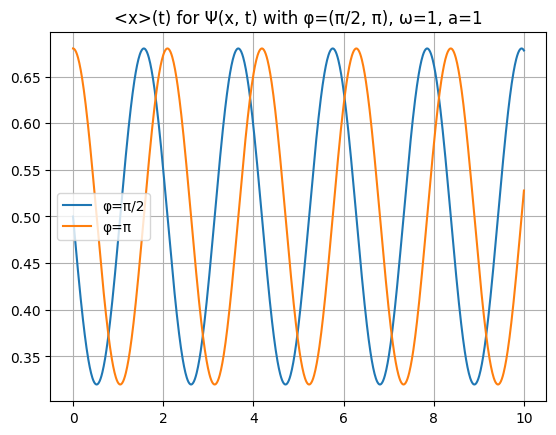

In [13]:
omega = 1
a = 1

def expected_position(t, phi):
  return a/2 - 16*a/9/np.pi**2*np.cos(3*omega*t - phi)

t_series = np.linspace(0, 10, 1000)
expected_x_series_1 = expected_position(t=t_series, phi=np.pi/2)
expected_x_series_2 = expected_position(t=t_series, phi=np.pi)

plt.plot(t_series, expected_x_series_1, label='φ=π/2')
plt.plot(t_series, expected_x_series_2, label='φ=π')
plt.legend()
plt.title('<x>(t) for Ψ(x, t) with φ=(π/2, π), ω=1, a=1')
plt.grid()
plt.show()



A**2*a**3/12


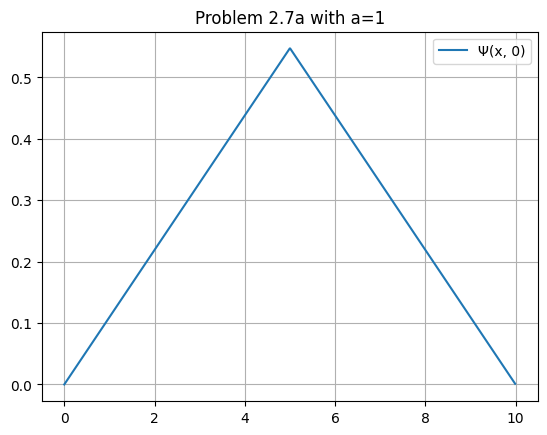

In [14]:
# Problem 2.7

A = sp.Symbol('A', positive=True)
a = sp.Symbol('a', positive=True)
x = sp.Symbol('x', positive=True)

normalization_integral = sp.integrate(A**2*x**2, (x, 0, a/2))+sp.integrate(A**2*(a-x)**2, (x, a/2, a))
print(normalization_integral)
# 1 = A**2a**3/12 -> A = sqrt(12/a^3)

def Psi_x_0(x, a):
  if x < a/2:
    return np.sqrt(12/a**3)*x
  elif x < a:
    return np.sqrt(12/a**3)*(a-x)

a = 10
x_series = np.linspace(0, a, 1000)
Psi_x_0_series = np.array([Psi_x_0(x=x, a=a) for x in x_series])
plt.plot(x_series, Psi_x_0_series, label='Ψ(x, 0)')
plt.legend()
plt.title('Problem 2.7a with a=1')
plt.grid()
plt.show()



In [15]:
a = sp.Symbol('a', positive=True)
x = sp.Symbol('x', positive=True)
n = sp.Symbol('n', integer=True, positive=True)
m = sp.Symbol('m', positive=True)
t = sp.Symbol('t', positive=True)
omega = sp.pi**2 * hbar / (2*m*a**2)

c_n = sp.sqrt(2/a)*(sp.integrate(sp.sin(n*sp.pi/a*x)*sp.sqrt(12/a**3)*x, (x, 0, a/2)) \
                    + sp.integrate(sp.sin(n*sp.pi/a*x)*sp.sqrt(12/a**3)*(a-x), (x, a/2, a)))
c_n = c_n.simplify()
sp.pprint(c_n)

Psi_x_t = sp.Sum(c_n * sp.sqrt(2/a)*sp.sin(n*sp.pi/a*x)*sp.exp(-sp.I*omega*t), (n, 1, sp.oo))

sp.pprint(Psi_x_t.simplify())

## Probability that the measurement would yield E_1

c_n_lambda = lambda n: 4*np.sqrt(6)*np.sin(np.pi*n/2)/np.pi**2/n**2

print('p(E_1) = ', c_n_lambda(1)**2)

# Expectation value of the energy
E_n  = n**2*sp.pi**2*hbar**2/2/m/a**2
expected_E = sp.Sum(c_n**2 * E_n, (n, 1, sp.oo))
print('Expected energy:')
sp.pprint(expected_E.simplify().doit())



        ⎛π⋅n⎞
4⋅√6⋅sin⎜───⎟
        ⎝ 2 ⎠
─────────────
     2  2    
    π ⋅n     
                   ∞                      
          2      _____                    
      -ⅈ⋅π ⋅h̅⋅t  ╲                        
      ──────────  ╲       ⎛π⋅n⎞    ⎛π⋅n⋅x⎞
           2       ╲   sin⎜───⎟⋅sin⎜─────⎟
        2⋅a ⋅m      ╲     ⎝ 2 ⎠    ⎝  a  ⎠
8⋅√3⋅ℯ          ⋅   ╱  ───────────────────
                   ╱            2         
                  ╱            n          
                 ╱                        
                 ‾‾‾‾‾                    
                 n = 1                    
──────────────────────────────────────────
                   2                      
                  π ⋅√a                   
p(E_1) =  0.9855342964496961
Expected energy:
   2
6⋅h̅ 
────
 2  
a ⋅m


Problem 2.9

Evaluate the expectation value

$$\langle H \rangle = \int \Psi(x, 0)^*\hat{H}\Psi(x, 0)dx$$

for the wave function in example 2.2

$$\Psi(x, 0) = \sqrt{\frac{30}{a^5}}x(a-x)$$

The Hamiltonian operator is

$$\hat{H} = -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x)$$

but we know V(x) = 0 inside the well, so

$$\hat{H} = -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}$$

In [16]:
hbar = sp.Symbol('hbar', positive=True)
m = sp.Symbol('m', positive=True)
a = sp.Symbol('a', positive=True)

Psi = sp.sqrt(30/a**5)*x*(a-x)

H_Psi = -hbar**2/2/m*sp.diff(Psi, x, x)

expected_H = sp.integrate(Psi * H_Psi, (x, 0, a))
print('Expected energy:')
sp.pprint(expected_H)

Expected energy:
   2
5⋅h̅ 
────
 2  
a ⋅m


# The Harmonic Oscillator

Classically, the motion of a harmonic oscillator is governed by Hooke's law

$$F = -kx = m\frac{d^2 x}{dt^2}$$

(ignoring friction), which has the solution

$$x(t) = A\sin(\omega t) + B\cos(\omega t), \quad \omega = \sqrt{\frac{k}{m}}$$

The potential energy is

$$V(x) = \frac{1}{2}kx^2$$

Quantum-mechanically, the problem is to solve the time-independent Schrodinger equation for the potential

$$V(x) = \frac{1}{2}m\omega^2 x^2$$

which is

$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} + \frac{1}{2}m\omega^2x^2\psi = E\psi$$

## Algebraic Method

Rewrite the Schrodinger equation

$$\frac{1}{2m}\left[\hat{p}^2 + (m\omega x)^2\right]\psi = E\psi$$

The basic idea is to factor the Hamiltonian

$$\hat{H} = \frac{1}{2m}\left[\hat{p}^2 + (m\omega x)^2\right]$$

But operators do not commute.

Examine the quantities $$\hat{a}_{\pm} = \frac{1}{\sqrt{2\hbar m \omega}}(\mp i\hat{p} + m\omega x)$$

for the product

$$\hat{a}_{-}\hat{a}_{+} = \frac{1}{2\hbar m \omega}\left[\hat{p}^2 + (m\omega x)^2\right] - \frac{i}{2\hbar}\left[x, \hat{p}\right]$$

with the commutator

$$[\hat{A}, \hat{B}] = \hat{A}\hat{B} - \hat{B}\hat{A}$$

**Proof of canonical commutation relation**

$$[x, \hat{p}]f(x) = \left[x(-i\hbar)\frac{d}{dx}f(x) - (-i\hbar)\frac{d}{dx}(xf)\right] = -i\hbar \left(x\frac{df}{dx} - x\frac{df}{dx} - f\right)$$

$$\therefore \quad [x, \hat{p}] = i\hbar$$

*Return to algebraic method*

Isolated the factored Hamiltonian

$$\hat{a}_{-}\hat{a}_{+} = \frac{1}{\hbar \omega} \hat{H} + \frac{1}{2}$$

$$\hat{H} = \hbar \omega \left(\hat{a}_{-}\hat{a}_{+} - \frac{1}{2}\right)$$

Plug it into the time-independent Schrodinger equation

$$\hbar \omega \left(\hat{a}_{-}\hat{a}_{+} - \frac{1}{2}\right)\psi = E\psi$$

If $\psi$ satisfies the Schrodinger equation with energy $E$, then $\hat{a}_+\psi$ satisfies the Schrodinger equation with energy $E+\hbar\omega$ and $\hat{a}_-\psi$ satsfies the Schrodinger equation with energy $E-\hbar\omega$.

There must be a ground state $\psi_0$ with the lowest energy $E_0$, so the lowering operator $\hat{a}_-$ would fail in the following way

$$\hat{a}_-\psi_0 = 0$$

$$\frac{1}{\sqrt{2\hbar m \omega}}\left( \hbar\frac{d}{dx} + m\omega x\right)\psi_0 = 0$$

which can be solved and normalized as a differential equation

$$\psi_0(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4}e^{-\frac{m\omega}{2\hbar}x^2}$$

Since $\hat{a}_-\psi_0 = 0$,

$$\hbar\omega(\hat{a}_+\hat{a}_- + \frac{1}{2})\psi_0 = E_0\psi_0 \quad\implies\quad E_0 = \frac{1}{2}\hbar\omega$$

$$\psi_n(x) = A_n(\hat{a}_+)^n\psi_0(x)$$
$$E_n = \left(n+\frac{1}{2}\right)\hbar\omega$$

$A_n$ is a normalization constant.


$$\psi_0(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4}e^{-\frac{m\omega}{2\hbar}x^2}$$

$$\psi_n(x) = A_n(\hat{a}_+)^n\psi_0(x)$$

$$\psi_1 = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4}\sqrt{\frac{2m\omega}{\hbar}}xe^{-\frac{m\omega}{2\hbar}x^2}$$

$$\psi_2 = A_2\hat{a}_+\psi_1$$

$$\psi_2 = \frac{A_2}{\sqrt{2\hbar m \omega}}\left(-\hbar\frac{d}{dx} + m\omega x\right)\left(\frac{m\omega}{\pi\hbar}\right)^{1/4}\sqrt{\frac{2m\omega}{\hbar}}xe^{-\frac{m\omega}{2\hbar}x^2}$$



In [17]:
A2 = sp.Symbol('A_2', positive=True)
omega = sp.Symbol('ω', positive=True)

distributed_term = x*sp.exp(-m*omega/2/hbar*x**2)
front_coefficient = (m*omega/sp.pi/hbar)**(1/4)*(2*m*omega/hbar)**(1/2)*A2/sp.sqrt(2*hbar*m*omega)

psi_2 = front_coefficient*(-hbar*sp.diff(distributed_term, x) + m*omega*x*distributed_term)
psi_2 = psi_2.simplify()
sp.pprint(psi_2)

                                                                       2   
                                                                   -m⋅x ⋅ω 
                                                                   ────────
                       -0.25     -1.25  0.25  0.25 ⎛         2  ⎞    2⋅h̅   
-0.707106781186548⋅√2⋅π     ⋅A₂⋅h̅     ⋅m    ⋅ω    ⋅⎝h̅ - 2⋅m⋅x ⋅ω⎠⋅ℯ        


$$\psi_2 = A_2(\frac{m\omega}{\pi\hbar^5})^{1/4}(\hbar - 2mx^2\omega)e^{-mx^2\omega/2\hbar}$$

In [18]:
normalization_integral = sp.integrate(psi_2, (x, -sp.oo, sp.oo)).doit()
sp.pprint(normalization_integral)

                 0.25     0.25  -0.25  -0.25
1.4142135623731⋅π    ⋅A₂⋅h̅    ⋅m     ⋅ω     



$$1 = \sqrt{2}A_2\left(\frac{\pi\hbar}{m\omega}\right)^{1/4}$$

$$A_2 = \left(\frac{m\omega}{4\pi\hbar}\right)^{1/4}$$


$$\psi_2 = \left(\frac{m\omega}{4\pi\hbar}\right)^{1/4}\left(\frac{m\omega}{\pi\hbar^5}\right)^{1/4}(\hbar - 2mx^2\omega)e^{-mx^2\omega/2\hbar}$$

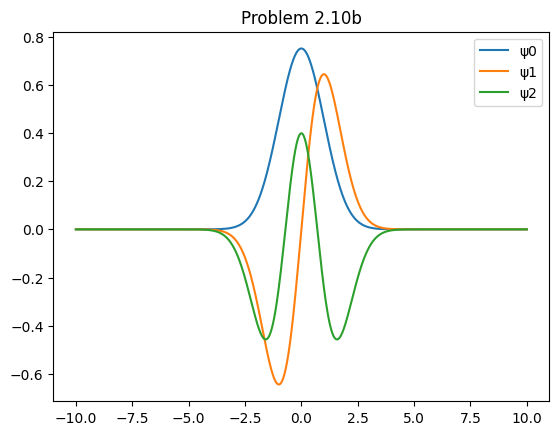

In [19]:
m = 1
omega = 1
hbar = 1

psi0 = lambda x: (m*omega/np.pi/hbar)**(1/4)*np.exp(-m*omega/2/hbar*x**2)
psi1 = lambda x: (m*omega/np.pi/hbar)**(1/4)*np.sqrt(2*m*omega/hbar)*x* \
np.exp(-m*omega/2/hbar*x**2)
psi2 = lambda x: (m**2*omega**2/4/np.pi**2/hbar**6)**(1/4)*(hbar-2*m*x**2*omega)\
*np.exp(-m*x**2*omega/2/hbar)

x_series = np.linspace(-10, 10, 1000)

psi_0_series = psi0(x_series)
psi_1_series = psi1(x_series)
psi_2_series = psi2(x_series)

plt.plot(x_series, psi_0_series, label='ψ0')
plt.plot(x_series, psi_1_series, label='ψ1')
plt.plot(x_series, psi_2_series, label='ψ2')
plt.legend()
plt.title('Problem 2.10b')
plt.show()

In [20]:
# Check the orthogonality of these by explicit integration
orthogonality_integral_1 = integrate(psi_0_series*psi_1_series, x_series)
print(orthogonality_integral_1)
orthogonality_integral_2 = integrate(psi_1_series*psi_2_series, x_series)
print(orthogonality_integral_2)
orthogonality_integral_3 = integrate(psi_0_series*psi_2_series, x_series)
print(orthogonality_integral_3)
# These integrals are all zero, so these functions are orthogonal.

5.551115123125783e-17
-2.7755575615628914e-17
0.0


In [21]:
m = sp.Symbol('m', positive=True)
omega = sp.Symbol('ω', positive=True)
hbar = sp.Symbol('hbar', positive=True)

psi0 = (m*omega/sp.pi/hbar)**(1/4)*sp.exp(-m*omega/2/hbar*x**2)
psi1 = (m*omega/sp.pi/hbar)**(1/4)*sp.sqrt(2*m*omega/hbar)*x* \
sp.exp(-m*omega/2/hbar*x**2)
psi2 = (m**2*omega**2/4/sp.pi**2/hbar**6)**(1/4)*(hbar-2*m*x**2*omega)\
*sp.exp(-m*x**2*omega/2/hbar)

expected_x_0 = sp.integrate(psi0*x*psi0, (x, -sp.oo, sp.oo))
print(expected_x_0)
expected_xsquared_0 = sp.integrate(psi0*x**2*psi0, (x, -sp.oo, sp.oo))
print(expected_xsquared_0)


0
hbar/(2*m*ω)


$$\langle p \rangle = \int \Psi^* p \Psi dx = -i\hbar\int \left(\Psi^*\frac{\partial \Psi}{\partial x}\right) dx$$

$$\langle p^2 \rangle = \int \Psi^* p^2 \Psi dx = \int \Psi^*[-i\hbar(\frac{\partial }{\partial x})][-i\hbar(\frac{\partial }{\partial x})] \Psi dx \\= -\hbar^2\int \Psi^*  \frac{\partial^2 \Psi}{\partial x^2} dx \\ = \hbar^2\int\frac{\partial\Psi}{\partial x}^*\frac{\partial\Psi}{\partial x}dx$$

In [22]:
dpsi0dx = sp.diff(psi0, x)
expected_p_0 = -hbar**2*sp.integrate(psi0*dpsi0dx, (x, -sp.oo, sp.oo))
print(expected_p_0)

d2psi0dx2 = sp.diff(dpsi0dx, x)
expected_psquared_0 = -hbar**2*sp.integrate(psi0*d2psi0dx2, (x, -sp.oo, sp.oo))
sp.pprint(expected_psquared_0)

#Check the uncertainty principle
combined_uncertainty_0 = sp.sqrt(expected_psquared_0 - expected_p_0**2)*\
sp.sqrt(expected_xsquared_0 - expected_x_0**2)
sp.pprint(combined_uncertainty_0)

0
 1.0  1.0  1.0
h̅   ⋅m   ⋅ω   
──────────────
      2       
 1.0
h̅   
────
 2  


In [23]:
expected_x_1 = sp.integrate(psi1*x*psi1, (x, -sp.oo, sp.oo))
print(expected_x_1)
expected_xsquared_1 = sp.integrate(psi1*x**2*psi1, (x, -sp.oo, sp.oo))
print(expected_xsquared_1)


dpsi1dx = sp.diff(psi1, x)
expected_p_1 = -hbar**2*sp.integrate(psi1*dpsi1dx, (x, -sp.oo, sp.oo))
print(expected_p_1)

d2psi1dx2 = sp.diff(dpsi1dx, x)
expected_psquared_1 = -hbar**2*sp.integrate(psi1*d2psi1dx2, (x, -sp.oo, sp.oo))
sp.pprint(expected_psquared_1)

#Check the uncertainty principle
combined_uncertainty_1 = sp.sqrt(expected_psquared_1 - expected_p_1**2)*\
sp.sqrt(expected_xsquared_1 - expected_x_1**2)
sp.pprint(combined_uncertainty_1)

0
3*hbar/(2*m*ω)
0
   1.0  1.0  1.0
3⋅h̅   ⋅m   ⋅ω   
────────────────
       2        
   1.0
3⋅h̅   
──────
  2   


The uncertainty relation $\sigma_x\sigma_p \geq \frac{\hbar}{2}$ is met by both cases.

Compute $\langle T \rangle$ and $\langle V \rangle$.

$$\langle V \rangle = \frac{1}{2}m\omega^2\langle x^2 \rangle$$

$$\langle T \rangle = \frac{\langle p^2 \rangle}{2m}$$



In [24]:
langle_T_rangle_0 = expected_psquared_0/2/m
langle_V_rangle_0 = expected_xsquared_0*m*omega**2/2

sp.pprint(langle_T_rangle_0 + langle_V_rangle_0)

langle_T_rangle_1 = expected_psquared_1/2/m
langle_V_rangle_1 = expected_xsquared_1*m*omega**2/2

sp.pprint(langle_T_rangle_1 + langle_V_rangle_1)

 1.0  1.0      
h̅   ⋅ω      h̅⋅ω
───────── + ───
    4        4 
   1.0  1.0        
3⋅h̅   ⋅ω      3⋅h̅⋅ω
─────────── + ─────
     4          4  


That is $\langle H \rangle = \frac{\hbar\omega}{2}$ in the $\psi_0$ state and $\langle H \rangle = \frac{3\hbar\omega}{2}$ in the $\psi_1$ state, which is exactly what we expect from equation 2.62.

$$x = \sqrt{\frac{\hbar}{2m\omega}}(\hat{a}_+ + \hat{a}_-)$$
$$\hat{p} = i\sqrt{\frac{\hbar m \omega}{2}}(\hat{a}_+ - \hat{a}_-)$$

Equation 2.66
$$\hat{a}_+\hat{a}_-\psi_n = n\psi_n$$

$$\hat{a}_-\hat{a}_+\psi_n = (n+1)\psi_n$$


Find $\langle x \rangle$, $\langle p \rangle$, $\langle x^2\rangle$, $\langle p^2\rangle$, and $\langle T \rangle$ using the method of example 2.5.

$$\langle x \rangle = \sqrt{\frac{\hbar}{2m\omega}}\int_{-\infty}^{\infty}\psi_n^*[\hat{a}_+ + \hat{a}_-]\psi_n dx$$

$$\langle x \rangle = \sqrt{\frac{\hbar}{2m\omega}}\left[\int_{-\infty}^{\infty}\psi_n^*\psi_{n+1} dx+\int_{-\infty}^{\infty}\psi_n^*\psi_{n-1} dx\right]$$
$$\langle x \rangle = 0$$ because the different states of the harmonic oscillator are orthogonal.

The same thing will happen to the momentum, because

$$\langle p \rangle = \sqrt{\frac{\hbar m \omega }{2}}\int_{-\infty}^{\infty}\psi_n^*[\hat{a}_+ - \hat{a}_-]\psi_n dx$$

$$\langle p \rangle = \sqrt{\frac{\hbar m \omega }{2}}\left[\int_{-\infty}^{\infty}\psi_n^*\psi_{n+1} -\int_{-\infty}^{\infty} \psi_n^*\psi_{n-1} dx\right]$$
$$\langle p \rangle = 0$$

$$\langle x^2 \rangle = \frac{\hbar}{2 m \omega } \int_{-\infty}^{\infty} \psi_n^*[(\hat{a}_+)^2 + (\hat{a}_+\hat{a}_-) + (\hat{a}_-\hat{a}_+) + (\hat{a}_-)^2]\psi_ndx$$

$$\langle x^2 \rangle = \frac{\hbar}{2 m \omega } \int_{-\infty}^{\infty} \psi_n^*[\psi_{n+2} + n\psi_n + (n+1)\psi_n + \psi_{n-2}]dx$$

$$\langle x^2 \rangle = \frac{\hbar}{2 m \omega } \int_{-\infty}^{\infty} \psi_n^*[n\psi_n + (n+1)\psi_n ]dx$$

$$\langle x^2 \rangle = \frac{\hbar}{2 m \omega }(2n+1)$$

$$\langle p^2 \rangle = -\frac{\hbar m \omega}{2} \int_{-\infty}^{\infty} \psi_n^*[(\hat{a}_+)^2 - (\hat{a}_+\hat{a}_-) - (\hat{a}_-\hat{a}_+) + (\hat{a}_-)^2]\psi_ndx$$

$$\langle p^2 \rangle = -\frac{\hbar m \omega}{2} \int_{-\infty}^{\infty} \psi_n^*[\psi_{n+2} - n\psi_n - (n+1)\psi_n + \psi_{n-2}]dx$$

$$\langle p^2 \rangle = -\frac{\hbar m \omega}{2}(-2n-1) = \frac{\hbar m \omega}{2}(2n+1)$$

$$\langle T \rangle = \frac{\langle p^2\rangle}{2m} = \frac{\hbar\omega}{4}(2n+1)$$

Check that the uncertainty principle is satisfied
$$(\langle x^2 \rangle -\langle x \rangle)(\langle p^2 \rangle - \langle p \rangle) = \frac{\hbar^2}{4}(2n+1)^2 \geq \frac{\hbar^2}{4}$$



In [25]:
# Problem 2.13

A = sp.Symbol('A', positive=True)

Psi_x_0 = A*(3*psi0 + 4*psi1)
probability_density = sp.conjugate(Psi_x_0)*Psi_x_0

normalization_integral = sp.integrate(probability_density, (x, -sp.oo, sp.oo))
print(normalization_integral)

25*A**2


$\therefore A=\frac{1}{5}$

In general:

$$\Psi(x, t) = \sum_{n=1}^{\infty} c_n \Psi_n(x, t)$$
$$\Psi_n(x, t) = \psi_n(x)e^{-iE_n t/\hbar}$$

For this problem:

$$\Psi(x, 0) = \frac{3}{5}\psi_0 + \frac{4}{5}\psi_1$$

$$c_n = \int \psi_n(x)^* \Psi(x, 0) dx = \frac{3}{5} \text{ for } n=0, \frac{4}{5} \text{ for } n=1, \text{ else } 0$$

$$c_0 = \frac{3}{5}, \quad c_1 = \frac{4}{5}, \quad c_n = 0 \text{ else } $$

Now recall the allowed energies:

$$E_0 = \frac{1}{2}\hbar\omega$$

$$E_1 = \frac{3}{2}\hbar\omega$$

And recall from Problem 2.10


$$\psi_0(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4}e^{-\frac{m\omega}{2\hbar}x^2}$$

$$\psi_1 = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4}\sqrt{\frac{2m\omega}{\hbar}}xe^{-\frac{m\omega}{2\hbar}x^2}$$

so

$$\Psi(x, t) = \frac{3}{5}\left(\frac{m\omega}{\pi\hbar}\right)^{1/4}e^{-\frac{m\omega}{2\hbar}x^2}e^{-i\omega t/2} \\ + \frac{4}{5} \left(\frac{m\omega}{\pi\hbar}\right)^{1/4}\sqrt{\frac{2m\omega}{\hbar}}xe^{-\frac{m\omega}{2\hbar}x^2}e^{-3i\omega t/2}$$


In [26]:
Psi_term_1 = 3/5*(m*omega/sp.pi/hbar)**(1/4)*sp.exp(-m*omega*x**2/2/hbar)*sp.exp(-sp.I*omega*t/2)
Psi_term_2 = 4/5*(m*omega/sp.pi/hbar)**(1/4)*sp.sqrt(2*omega*m/hbar)*x*sp.exp(-m*omega*x**2/2/hbar)*sp.exp(-3*sp.I*omega*t/2)
Psi_x_t = Psi_term_1 + Psi_term_2

probability_density = sp.conjugate(Psi_x_t)*Psi_x_t

expected_position = sp.integrate(probability_density*x, (x, -sp.oo, sp.oo))
sp.pprint(sp.simplify(expected_position))

         0.5  -0.5  -0.5         
0.48⋅√2⋅h̅   ⋅m    ⋅ω    ⋅cos(t⋅ω)


In [27]:
# Ehrenfest's theorem
expected_momentum_Ehrenfest = sp.diff(expected_position, t)
sp.pprint(sp.simplify(expected_momentum_Ehrenfest))

# Explicit integration
integrand = sp.conjugate(Psi_x_t)*sp.diff(Psi_x_t, x)
expected_momentum_explicit = -sp.I * hbar * sp.integrate(integrand, (x, -sp.oo, sp.oo))
sp.pprint(sp.simplify(expected_momentum_explicit))

          0.5  -0.5  0.5         
-0.48⋅√2⋅h̅   ⋅m    ⋅ω   ⋅sin(t⋅ω)
          0.5  0.5  0.5         
-0.48⋅√2⋅h̅   ⋅m   ⋅ω   ⋅sin(t⋅ω)


$$c_0 = \frac{3}{5}, \quad c_1 = \frac{4}{5}, \quad c_n = 0 \text{ else } $$

$$E_0 = \frac{1}{2}\hbar\omega$$

$$E_1 = \frac{3}{2}\hbar\omega$$

Energy $E_0$ is found with probability $9/25$, and $E_1$ is found with probability $16/25$, so the expectation value of the energy is



In [28]:
expected_energy = 9/16*1/2*hbar*omega + 16/25*3/2*hbar*omega
print(expected_energy)

1.24125*hbar*ω


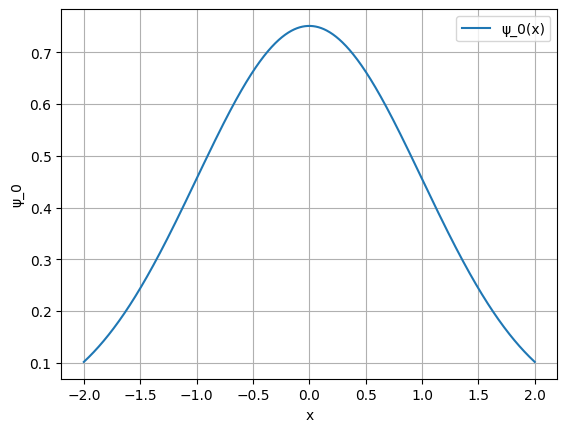

In [29]:
import numpy as np
from matplotlib import pyplot as plt

# Ground state wave function
def psi_0(x, m, omega, hbar):
  return (m*omega/np.pi/hbar)**(1/4)*np.exp(-m*omega/2/hbar*x**2)

m = 1
omega = 1
hbar = 1

x_array=np.linspace(-2, 2, 1000)
psi_array = np.array([psi_0(x, m, omega, hbar) for x in x_array])
plt.plot(x_array, psi_array, label='ψ_0(x)')
plt.xlabel('x')
plt.ylabel('ψ_0')
plt.legend()
plt.grid()
plt.show()



# The ladder operator is

$$\hat{a}_+ = \frac{1}{\sqrt{2\hbar m \omega }}(-i\hat{p}+m\omega x)$$
$$\hat{a}_- = \frac{1}{\sqrt{2\hbar m \omega }}(+i\hat{p}+m\omega x)$$

# the momentum operator is

$$\hat{p} = -i\hbar\frac{\partial}{\partial x}$$

# The ladder operator is applied

$$\psi_n = \frac{1}{\sqrt{n!}}(\hat{a}_+)^n\psi_0$$

In [30]:
# Applying ladder operators
import sympy as sp
from math import factorial

x = sp.Symbol('x', real=True)
m = sp.Symbol('m', real=True)
hbar = sp.Symbol('hbar', positive=True)
omega = sp.Symbol('ω', positive=True)


psi_0_sp = (m*omega/sp.pi/hbar)**(1/4)*sp.exp(-m*omega/2/hbar*x**2)

# Let n be the integer level of the harmonic oscillator
# Find \psi_n (equation 2.68)

def psi_n(n, psi_0_sp):
  psi_collection = [psi_0_sp]
  a_plus_k_psi0 = psi_0_sp
  for k in range(1, n):
    a_plus_k_psi0 = 1/sp.sqrt(2*hbar*m*omega)*(-hbar*sp.diff(a_plus_k_psi0, x)\
                                                  +m*omega*x*a_plus_k_psi0)
    psi_k = 1/sp.sqrt(factorial(k))*a_plus_k_psi0
    psi_collection.append(psi_k.simplify())
  return psi_collection

psi_collection = psi_n(3, psi_0_sp)

# The Free Particle

The potential of a free particle is $V(x)=0$ everywhere, and the time-independent Schrodinger equation reads

$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} = E\psi$$

or $$\frac{d^2\psi}{dx^2} = -k^2\psi$$ with $$k=\frac{\sqrt{2mE}}{\hbar}$$

$$\Psi(x, t) = Ae^{ik(x-\frac{\hbar k}{2m}t)} + Be^{-ik(x+\frac{\hbar k}{2m}t)}$$

We can simplify this by writing

$$\Psi_k(x, t) = Ae^{i(kx - \frac{\hbar k^2}{2m}t)}$$ with $k = \pm \frac{\sqrt{2mE}}{\hbar}$, negative for traveling to the left and positive for traveling to the right.

Now there is a continuous range of possible values of $k$ (therefore also a continuous range of possible energy values). Energy is continuous instead of discrete because there is no boundary on the potential.

We define $\phi(k)$ as the Fourier transform of the initial wave function

$$\phi(k) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{+\infty}\Psi(x, 0)e^{-ikx}dx$$

and the general solution is a reverse Fourier transform with added time dependence

$$\Psi(x, t) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty}\phi(k)e^{i(kx-\frac{\hbar k^2}{2m}t)}dk$$

Problem 2.17

$$Ae^{ikx}+Be^{-ikx} = A(\cos(kx) + i\sin(kx)) + B(\cos(kx) - i\sin(kx)) = C\cos(kx) + D\sin(kx)$$

$$C = A + B, \quad D = i(A-B)$$

Problem 2.18

Probability current in one dimension

$$ j(x, t) \equiv \frac{i\hbar}{2m} \left( \Psi \frac{\partial\Psi^*}{\partial x} - \Psi^* \frac{\partial\Psi}{\partial x} \right) $$


$$ j(x, t) = \frac{\hbar}{m} \text{Im}\left( \Psi^* \frac{\partial\Psi}{\partial x} \right) $$




In [31]:
k = sp.Symbol('k', real=True)
A = sp.Symbol('A', real=True)

Psi_k_x_t = A*sp.exp(sp.I*(k*x - hbar * k**2 / 2 / m * t))

probability_current = hbar/m * sp.im(sp.conjugate(Psi_k_x_t)* sp.diff(Psi_k_x_t, x))
probability_current = probability_current.simplify()
sp.pprint(probability_current)

 2    
A ⋅h̅⋅k
──────
  m   


It appears that probability flows to the right (positive x-direction) because there is a positive probability current.

In [32]:
# Problem 2.20

x = sp.Symbol('x', real=True)
t = sp.Symbol('t', real=True)
k = sp.Symbol('k', real=True)
a = sp.Symbol('a', positive=True)
A = sp.Symbol('A', positive=True)
m = sp.Symbol('m', positive=True)
hbar = sp.Symbol('hbar', positive=True)

Psi_x_0 = A * sp.exp(-a*sp.Abs(x))

# Normalize Psi_x_0
normalization_integral = sp.integrate(sp.conjugate(Psi_x_0) * Psi_x_0, (x, -sp.oo, sp.oo))
sp.pprint(normalization_integral)
# Therefore A = sqrt(a)
Psi_x_0 = sp.sqrt(a) * sp.exp(-a*sp.Abs(x))

# Find $\phi(k)$ with the Fourier transform: piecewise solution
phi_k = 1/sp.sqrt(2*sp.pi)*sp.integrate(Psi_x_0*sp.exp(-sp.I*k*x), (x, -sp.oo, sp.oo))
phi_k = phi_k.expand().doit().simplify()
sp.pprint(phi_k)

 2
A 
──
a 
⎧              3/2                       
⎪          √2⋅a                          
⎪        ────────────           for k > 0
⎪           ⎛ 2    2⎞                    
⎪        √π⋅⎝a  + k ⎠                    
⎪                                        
⎪      ∞                                 
⎨      ⌠                                 
⎪      ⎮   -(a⋅│x│ + ⅈ⋅k⋅x)              
⎪√2⋅√a⋅⎮  ℯ                 dx           
⎪      ⌡                                 
⎪      -∞                                
⎪─────────────────────────────  otherwise
⎪            2⋅√π                        
⎩                                        


Since the denominator is always positive, $\phi(k) = \sqrt{\frac{2a^3}{\pi}}\frac{1}{a^2+k^2}$ is the general solution for all values of $k$. Sympy returned a piecewise solution because of the logical path it took in the derivation with the square / square root. It solved an integral with respect to $x$, where $k$ is a constant; there is no mathematical or physical reason why $k$ cannot be negative.

     ∞                       
     ⌠                       
     ⎮                2      
     ⎮          -ⅈ⋅h̅⋅k ⋅t    
     ⎮          ──────────   
     ⎮   ⅈ⋅k⋅x     2⋅m       
 3/2 ⎮  ℯ     ⋅ℯ             
a   ⋅⎮  ────────────────── dk
     ⎮        2    2         
     ⎮       a  + k          
     ⌡                       
     -∞                      
─────────────────────────────
              π              
Symbolic probability density computed
Probability density lambda computed


/usr/local/lib/python3.12/dist-packages/scipy/integrate/_quadpack_py.py:609: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagie(func, bound, infbounds, args, full_output,
<lambdifygenerated-1>:2: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return a**3*conjugate(quad(lambda k: exp(1j*k*x)*exp(-1/2*1j*hbar*k**2*t/m)/(a**2 + k**2), -inf, inf)[0])*quad(lambda k: exp(1j*k*x)*exp(-1/2*1j*hbar*k**2*t/m)/(a**2 + k**2), -inf, inf)[0]/pi**2
<lambdifygenerated-1>:2: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be use

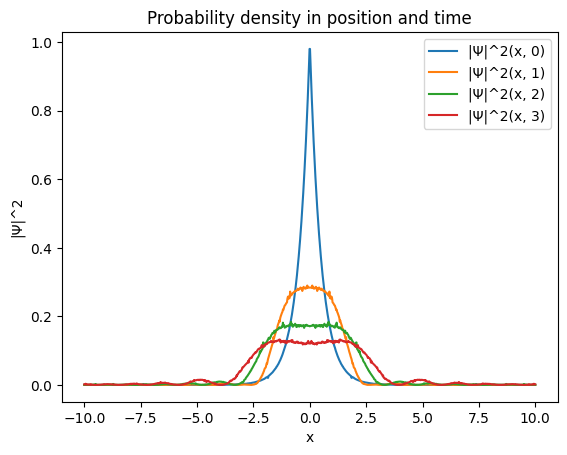

In [33]:
phi_k = sp.sqrt(2*a**3/sp.pi)*1/(a**2+k**2)
Psi_x_t = 1/sp.sqrt(2*sp.pi)*sp.integrate(phi_k * \
                                          sp.exp(sp.I*(k*x - hbar * k**2 / 2 / m*t)), \
                                          (k, -sp.oo, sp.oo))
Psi_x_t = Psi_x_t.expand().doit().simplify()
sp.pprint(Psi_x_t)

probability_density = sp.conjugate(Psi_x_t)*Psi_x_t
print('Symbolic probability density computed')

numerical_probability_density = sp.lambdify([a, k, x, hbar, t, m], probability_density)
print('Probability density lambda computed')

# Numerical plotting of probability density
a = 1
k = 1
hbar = 1
m = 1
t_series = [0, 1, 2, 3]
x_series = np.linspace(-10, 10, 1000)

for t in t_series:
  # Numerical probability density series
  npd_series = np.array([
      numerical_probability_density(a=a, k=k, x=x, hbar=hbar, m=m, t=t)
      for x in x_series])
  plt.plot(x_series, npd_series, label=f'|Ψ|^2(x, {t})')
plt.title('Probability density in position and time')
plt.ylabel('|Ψ|^2')
plt.xlabel('x')
plt.legend()
plt.show()



If $a$ is very large or $a$ is very small, the wave function is zero.

       2
√2⋅√π⋅A 
────────
  2⋅√a  
                                       2
                      -0.25  0.25  -a⋅x 
0.840896415253715⋅√2⋅π     ⋅a    ⋅ℯ     
     ∞                       
     ⌠                       
     ⎮                2      
     ⎮          -ⅈ⋅h̅⋅k ⋅t    
     ⎮          ──────────   
     ⎮   ⅈ⋅k⋅x     2⋅m       
 3/2 ⎮  ℯ     ⋅ℯ             
a   ⋅⎮  ────────────────── dk
     ⎮        2    2         
     ⎮       a  + k          
     ⌡                       
     -∞                      
─────────────────────────────
              π              
Probability density lambda computed


<lambdifygenerated-2>:2: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return a**3*conjugate(quad(lambda k: exp(1j*k*x)*exp(-1/2*1j*hbar*k**2*t/m)/(a**2 + k**2), -inf, inf)[0])*quad(lambda k: exp(1j*k*x)*exp(-1/2*1j*hbar*k**2*t/m)/(a**2 + k**2), -inf, inf)[0]/pi**2
<lambdifygenerated-2>:2: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return a**3*conjugate(quad(lambda k: exp(1j*k*x)*exp(-1/2*1j*hbar*k**2*t/m)/(a**2 + k**2), -inf, inf)[0])*quad(lambda k: exp(1j*k*x)*exp(-1/2*1j*hbar*k**2*t/m)/(a**2 + k**2), -inf, inf)[0]/pi**2


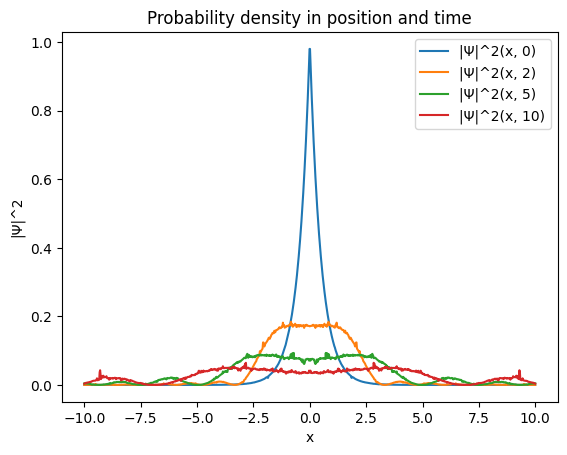

In [34]:
# Problem 2.21 The gaussian wave packet

x = sp.Symbol('x', real=True)
t = sp.Symbol('t', real=True)
k = sp.Symbol('k', real=True)
a = sp.Symbol('a', positive=True)
A = sp.Symbol('A', positive=True)
m = sp.Symbol('m', positive=True)
hbar = sp.Symbol('hbar', positive=True)

Psi_x_0 = A * sp.exp(-a*x**2)

# Normalize Psi_x_0
probability_density_0 = sp.conjugate(Psi_x_0)*Psi_x_0
normalization_integral = sp.integrate(probability_density_0, (x, -sp.oo, sp.oo))
sp.pprint(normalization_integral)

# Therefore
A = (a/2/sp.pi)**(1/4)*sp.sqrt(2)
Psi_x_0 = A * sp.exp(-a*x**2)
sp.pprint(Psi_x_0)

# Fourier transform the initial wave function
phi_k_t = 1/sp.sqrt(2*sp.pi)*sp.integrate(Psi_x_0*sp.exp(-sp.I*k*x), (x, -sp.oo, sp.oo))

# Find the general solution with the inverse Fourier transform
Psi_x_t = 1/sp.sqrt(2*sp.pi) *sp.integrate(phi_k * sp.exp(sp.I*(k*x - hbar * k**2 / 2 / m * t)), (k, -sp.oo, sp.oo))
Psi_x_t = Psi_x_t.expand().doit().simplify()
sp.pprint(Psi_x_t)

# Find |\Psi(x, t)|^2
probability_density = sp.conjugate(Psi_x_t) * Psi_x_t

# Numerical plotting of probability density
numerical_probability_density = sp.lambdify([a, k, x, hbar, t, m], probability_density)
print('Probability density lambda computed')
a = 1
k = 1
hbar = 1
m = 1
t_series = [0, 2, 5, 10]
x_series = np.linspace(-10, 10, 1000)

for t in t_series:
  # Numerical probability density series
  npd_series = np.array([
      numerical_probability_density(a=a, k=k, x=x, hbar=hbar, m=m, t=t)
      for x in x_series])
  plt.plot(x_series, npd_series, label=f'|Ψ|^2(x, {t})')
plt.title('Probability density in position and time')
plt.ylabel('|Ψ|^2')
plt.xlabel('x')
plt.legend()
plt.show()


 Problem 2.21 Continued

 $$\Psi(x, 0) = \left(\frac{2a}{\pi}\right)^{1/4}e^{-ax^2}$$

 $$\phi(k) = \frac{1}{\sqrt{2\pi}}\int \left(\frac{2a}{\pi}\right)^{1/4}e^{-ax^2} e^{-ikx} dx$$

 $$\phi(k) = \frac{1}{\sqrt{2\pi}}\int \left(\frac{2a}{\pi}\right)^{1/4}e^{-ax^2-ikx} dx$$

In [35]:
a = sp.Symbol('a', positive=True)
b = sp.Symbol('b')
x = sp.Symbol('x', real=True)

integrand = sp.exp(-(a*x**2+b*x))
hint_integral = sp.integrate(integrand, (x, -sp.oo, sp.oo))
hint_integral = hint_integral.expand().doit().simplify()
sp.pprint(hint_integral)

     2 
    b  
    ───
    4⋅a
√π⋅ℯ   
───────
  √a   


According to our sympy calculator,


$$\int_{-\infty}^{\infty}e^{-(ax^2+bx)}dx = \sqrt{\frac{\pi}{a}}e^{\frac{b^2}{4a}}$$

 $$\phi(k) = \frac{1}{\sqrt{2\pi}} \left(\frac{2a}{\pi}\right)^{1/4}\int e^{-ax^2-ikx} dx$$

 In our case, $a=a$ and $b=ik$

 $$\phi(k) = \frac{1}{\sqrt{2\pi}} \left(\frac{2a}{\pi}\right)^{1/4}\sqrt{\frac{\pi}{a}}e^{\frac{-k^2}{4a}}$$

 $$\Psi(x, t) = \frac{1}{\sqrt{2\pi}}\frac{1}{\sqrt{2\pi}} \left(\frac{2a}{\pi}\right)^{1/4}\sqrt{\frac{\pi}{a}}\int e^{\frac{-k^2}{4a}}e^{i(kx-\frac{\hbar k^2}{2m}t)} dk$$


$$\int e^{\frac{-k^2}{4a}}e^{i(kx-\frac{\hbar k^2}{2m}t)} dk = \int e^{ikx - k^2(\frac{i\hbar t}{2m}+\frac{1}{4a})} dk$$

$$c = ix, \quad d = (\frac{i\hbar t}{2m}+\frac{1}{4a})$$

$$\int e^{\frac{-k^2}{4a}}e^{i(kx-\frac{\hbar k^2}{2m}t)} dk = \int e^{ck - dk^2} = \sqrt{\frac{\pi}{d}}e^{\frac{c^2}{4d}} = \sqrt{\frac{\pi}{(\frac{i\hbar t}{2m}+\frac{1}{4a})}}e^{\frac{-x^2}{4(\frac{i\hbar t}{2m}+\frac{1}{4a})}}$$

 $$\Psi(x, t) = \frac{1}{\sqrt{2\pi}}\frac{1}{\sqrt{2\pi}} \left(\frac{2a}{\pi}\right)^{1/4}\sqrt{\frac{\pi}{a}} \sqrt{\frac{\pi}{(\frac{i\hbar t}{2m}+\frac{1}{4a})}}e^{\frac{-x^2}{4(\frac{i\hbar t}{2m}+\frac{1}{4a})}}$$


                                                2      
                                          -a⋅m⋅x       
                                      ─────────────────
                      -0.25  0.25     2⋅ⅈ⋅a⋅h̅⋅t + 1.0⋅m
0.594603557501361⋅√2⋅π     ⋅a    ⋅√m⋅ℯ                 
───────────────────────────────────────────────────────
                    _________________                  
                  ╲╱ ⅈ⋅a⋅h̅⋅t + 0.5⋅m                   
Probability density lambda computed


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


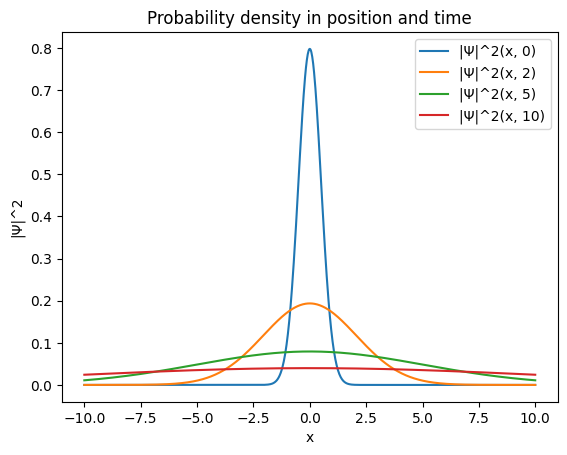

In [36]:
x = sp.Symbol('x', real=True)
t = sp.Symbol('t', real=True)
k = sp.Symbol('k', real=True)
a = sp.Symbol('a', positive=True)
A = sp.Symbol('A', positive=True)
m = sp.Symbol('m', positive=True)
hbar = sp.Symbol('hbar', positive=True)

Psi_x_t = sp.simplify(1/2/sp.pi * (2*a/sp.pi)**(1/4)*sp.sqrt(sp.pi/a)*\
                      sp.sqrt(sp.pi/(sp.I*hbar*t/2/m + 1/4/a))*\
                      sp.exp(-x**2/(4*(sp.I*hbar*t/2/m + 1/4/a))))
sp.pprint(Psi_x_t)

# Find |\Psi(x, t)|^2
probability_density = sp.conjugate(Psi_x_t) * Psi_x_t

# Numerical plotting of probability density
numerical_probability_density = sp.lambdify([a, k, x, hbar, t, m], probability_density)
print('Probability density lambda computed')
a = 1
k = 1
hbar = 1
m = 1
t_series = [0, 2, 5, 10]
x_series = np.linspace(-10, 10, 1000)

for t in t_series:
  # Numerical probability density series
  npd_series = np.array([
      numerical_probability_density(a=a, k=k, x=x, hbar=hbar, m=m, t=t)
      for x in x_series])
  plt.plot(x_series, npd_series, label=f'|Ψ|^2(x, {t})')
plt.title('Probability density in position and time')
plt.ylabel('|Ψ|^2')
plt.xlabel('x')
plt.legend()
plt.show()


## Delta Function Potential

$$\delta(x)$$ has an infinite spike at the origin with area 1, and $$\delta(x-a)$$ has an infinite spike of area 1 at the point $x=a$.

The delta function has the property:
$$f(x)\delta(x-a) = f(a)\delta(x-a)$$

$$\int_{-\infty}^{\infty} f(x)\delta(x-a) dx = f(a)\int_{-\infty}^{\infty} \delta (x-a) dx = f(a)$$


Problem 2.22

a)

$$\int_{-3}^{+1}(x^3 - 3x^2 + 2x - 1)\delta(x+2)dx = \int_{-\infty}^{+\infty}(x^3 - 3x^2 + 2x - 1)\delta(x+2)dx = -8 - 12 - 4 -1 = -25$$


In [37]:
x = sp.Symbol('x')

polynomial = x**3 -3*x**2 + 2*x - 1
integrand = polynomial*sp.DiracDelta(x+2)
integral = sp.integrate(integrand, (x, -3, 1))
sp.pprint(integral)

-25


$$\int_0^\infty [\cos(3x) + 2]\delta(x-\pi)dx = \cos(3\pi)+2 = -1 + 2 = 1$$

In [38]:
x = sp.Symbol('x')

function = sp.cos(3*x) + 2
integrand = function * sp.DiracDelta(x-sp.pi)
integral = sp.integrate(integrand, (x, 0, sp.oo))
sp.pprint(integral)


1


In this case, the bounds of the integral do not contain the spike, so the integral is zero.

$$\int_{-1}^{1}\exp(|x|+3)\delta(x-2)dx = 0$$

**Problem 2.23**

On the property that two expressions $D_1$ and $D_2$ involving delta functions are equal if

$$\int_{-\infty}^{\infty} f(x) D_1 dx = \int_{-\infty}^{\infty} f(x) D_2 dx$$

a)

Show that $$\delta(cx) = \frac{1}{|c|}\delta(x)$$

The first integral is

$$\int_{-\infty}^{\infty} f(x) \delta (cx) dx = \int_{c\times-\infty}^{c\times\infty} f(\frac{u}{c})\frac{1}{c} \delta (u) du \\= \frac{f(0)}{c}\int_{c\times-\infty}^{c\times\infty} \delta(u)du = \frac{f(0)}{|c|} $$

because $\int_{c\times-\infty}^{c\times\infty} \delta(u)du$ is negative one if $c$ is negative and one if $c$ is positive.

The other integral is

$$\int_{-\infty}^{\infty}\frac{f(x)}{|c|}\delta(x)dx = \frac{f(0)}{|c|}\int_{-\infty}^{\infty}\delta (x) dx = \frac{f(0)}{|c|}$$

These integrals are the same, so the delta functions are the same

$$\delta(cx) = \frac{1}{|c|}\delta(x)$$

b)

For the step function $\theta$, show that $$\frac{d\theta}{dx} = \delta(x)$$

The integral is
$$\int_{-\infty}^{\infty} f(x) \frac{d\theta}{dx}  = f(x)\theta(x)|_{-\infty}^{\infty} - \int{-\infty}^{\infty} \theta(x)\frac{df}{dx} dx \\= f(\infty) + 0 - \left[\int_{-\infty}^0 0 \times \frac{df}{dx} dx + \int_{0}^{\infty} \frac{df}{dx}dx\right]\\ = f(\infty) - (f(\infty) - f(0)) = f(0)$$

which is the same behavior under the integral as the delta function itself $$\int_{-\infty}^{\infty}f(x)\delta(x)dx= f(0)$$

therefore $$\frac{d\theta}{dx} = \delta (x)$$


In [39]:
# Problem 2.24

x = sp.Symbol('x', real=True)
alpha = sp.Symbol('alpha', positive=True)
hbar = sp.Symbol('hbar', positive=True)
m = sp.Symbol('m', positive=True)
t = sp.Symbol('t', positive=True)

psi = sp.sqrt(m*alpha)/hbar * sp.exp(-m*alpha*sp.Abs(x)/hbar**2)*sp.exp(sp.I*m*alpha**2*t/(2*hbar)**3)

# Calculate expected position
#integrand = (sp.sqrt(m*alpha)/hbar)*sp.exp(-2*m*alpha*sp.Abs(x)/hbar**2)*x
integrand = sp.conjugate(psi)*x*psi
expected_position = sp.integrate(integrand, (x, -sp.oo, sp.oo))
sp.pprint(expected_position)

# Calculate expected position squared
#integrand = (sp.sqrt(m*alpha)/hbar)*sp.exp(-2*m*alpha*sp.Abs(x)/hbar**2)*x**2
integrand = sp.conjugate(psi)*x**2*psi
expected_position_squared = sp.integrate(integrand, (x, -sp.oo, sp.oo))
sp.pprint(expected_position_squared)

# Calculate expected momentum
dpsidx = sp.diff(psi, x)
expected_momentum = -sp.I*hbar*sp.integrate(sp.conjugate(psi)*dpsidx, (x, -sp.oo, sp.oo))
sp.pprint(expected_momentum)

# Calculate expected momentum squared
integrand = sp.conjugate(dpsidx)*dpsidx
#d2psidx2 = sp.diff(dpsidx, x)
#integrand = sp.conjugate(psi)*d2psidx2
expected_momentum_squared = hbar**2*sp.integrate(integrand, (x, -sp.oo, sp.oo))
sp.pprint(expected_momentum_squared)

# Check the uncertainty relation
combined_uncertainty = sp.sqrt(expected_position_squared - expected_position**2)\
*sp.sqrt(expected_momentum_squared - expected_momentum**2)
sp.pprint(combined_uncertainty)




0
   4   
  h̅    
───────
   2  2
2⋅α ⋅m 
0
 2  2
α ⋅m 
─────
  2  
 h̅   
√2⋅h̅
────
 2  


$$\frac{\sqrt{2}\hbar}{2} \geq \frac{\hbar}{2}$$ the uncertainty relation has been satisfied.

In [40]:
# Problem 2.30 with equation 2.154
x = sp.Symbol('x', real = True)
F = sp.Symbol('F', real = True)
D = sp.Symbol('D', real = True)
l = sp.Symbol('l', positive = True)
a = sp.Symbol('a', positive = True)
kappa = sp.Symbol('kappa', positive=True)

psi_x = sp.Piecewise((F*sp.exp(-kappa*x), x >= a),
                     (D*sp.cos(l*x), sp.And(x >= 0, x < a)),
                     (D*sp.cos(-l*x), sp.And(x > -a, x < 0)),
                     (F*sp.exp(kappa*x), x <= -a))

probability_density = sp.conjugate(psi_x)*psi_x

normalization_integral = sp.integrate(probability_density, (x, -sp.oo, sp.oo))
sp.pprint(sp.simplify(normalization_integral))



        2               2  -2⋅a⋅κ
 2     D ⋅sin(2⋅a⋅l)   F ⋅ℯ      
D ⋅a + ───────────── + ──────────
            2⋅l            κ     


$$D^2 a + D^2\frac{\sin(2al)}{2l} + F^2 \frac{e^{-2a\kappa}}{\kappa}=1$$

Plugging in formulas from book Eq. 2.155 2.156

$$\frac{D}{F} = \frac{e^{-\kappa a}}{\cos(la)}$$

$$\frac{1}{l} \cos(la) = \frac{1}{\kappa}\sin(la)$$

$$\frac{1}{D^2} = a + \frac{\sin(al)\cos(al)}{l}+\frac{\cos(la)^2}{\kappa} = a+\frac{1}{\kappa}$$

$$D = \frac{1}{\sqrt{a+\frac{1}{\kappa}}}$$

$$F = \frac{\cos(la)}{e^{-\kappa a}\sqrt{a+\frac{1}{\kappa}}}$$



# Chapter 3

Problem 3.1

a)

Show that if $f$ and $g$ are square-integrable, then $f+g$ is square-integrable.

$$\int_a^b |f(x)|^2 dx = \langle f | f \rangle < \infty$$
$$\int_a^b |g(x)|^2 dx = \langle g | g \rangle < \infty$$

$$\langle f + g | f + g \rangle = \int_{a}^b (f+g)^*(f+g)dx = \langle f | f \rangle + \langle g | f \rangle + \langle f | g \rangle + \langle g | g \rangle$$

The Cauchy-Schwartz inequality implies

$$|\langle g | f \rangle | \leq \sqrt{\langle f | f \rangle \langle g | g \rangle }$$

$$|\langle f | g \rangle | \leq \sqrt{\langle f | f \rangle \langle g | g \rangle }$$

$$\therefore \quad \langle f + g |f+ g \rangle < \infty$$

$f+g$ is square-integrable when $f$ and $g$ are square-integrable. This is vector addition, and the set of all square-integrable functions is a vector space. The space of all normalized functions is a subspace, and also a vector space with $|\langle g | f \rangle | \leq 1$.

b)

$\langle f | g \rangle = \int_a^b f(x)^*g(x) dx$ is an inner product because it satisfies the following properties

i)

$$\langle \beta | \alpha \rangle = \int_a^b \beta(x)^*\alpha(x) dx \\ \langle \alpha| \beta \rangle ^*  =  \int_a^b \alpha(x)\beta(x)^* dx \\ \therefore\quad \langle \beta | \alpha \rangle = \langle \alpha | \beta \rangle^*$$

ii)


$$\langle \alpha |\alpha \rangle = \int_a^b | \alpha(x)|^2 dx$$
$$|\alpha(x)|^2 \geq 0 \quad\therefore\quad \langle \alpha | \alpha \rangle \geq 0$$

iii)

$$\int_a^b \alpha(x)^* (b\beta(x) + c\gamma(x))dx = b \int_a^ \alpha(x)^*\beta(x)dx + c\int_a^b \alpha(x)^*\gamma(x) dx $$
$$\therefore\quad \langle\alpha|(b|\beta\rangle + c | \gamma\rangle) = b\langle \alpha | \beta \rangle + c \langle \alpha | \gamma \rangle$$

These three properties make $\langle f | g \rangle = \int_a^b f(x)^*g(x) dx$ an inner product.


